<a href="https://colab.research.google.com/github/heamy121/mmai/blob/master/homework/homework-2/colab_nb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **SAVE A COPY OF THIS NOTEBOOK TO PUT ANSWERS INTO**

#Part 1 (Reading Assignment), 20 points

**Reminder: there are 5 reading assignments, 3% each for 15% total of your final grade.**

The reading assignment consists of two papers - [one on alignment before fusion](https://arxiv.org/abs/2107.07651), and one on the [Platonic Representation Hypothesis](https://arxiv.org/pdf/2405.07987). Read both papers and then answer the following questions:

1. Explain the implications of 'align before fuse' on your tasks of interest. at which degree, and what type of fusion needs to be performed? And what level of alignment would you need to perform for your data, so that subsequent fusion or representation learning is successful?
2. How can you perform controlled experiments to validate the types of fusion and/or alignment needed for your tasks? What are some challenges you foresee in fusing and aligning your data?
3. Explain the implications of 'platonic representation hypothesis' on your tasks of interest. Do you believe alignment between modalities would automatically emerge as models trained on your data are scaled up?
4. What are some reasons why alignment would not emerge i.e., counter-arguments to the platonic representation hypothesis? You are encouraged to search for follow-up works to the original paper that both support and counter the original arguments.
5. What experiments would you propose to validate the existence and emergence of alignment in your tasks?
6. Can you also think of some downsides of strongly (or perfectly) aligning your data modalities? How can you design experiments to validate that these risks are not present in your trained models?

#Part 2 (Homework Assignment), 100 points

**Reminder: there are 5 homework assignments, 7% each for 35% total of your final grade.**

For this assignment, we will finally begin playing with some of the concepts discussed in the class regarding multimodal modeling.

The first part will deal with Einsum and Tensors.

# Problem 1: Tensors (5 points)

(5 pts) Let's start with tensors. A tensor represents an N-th dimensional array of numbers. In machine learning, they are used to represent data as they can efficiently represent complex data to train with. We traditionally use PyTorch as the package of choice to work with tensors. Fill in the code below with the right tensor operations. Feel free to consult the documentation and the PyTorch tutorials for help.

In [ ]:
import torch
mat_A = torch.rand(3, 2)
mat_B = torch.rand(2, 3)

In [ ]:
# Common PyTorch operations

# Adding
mat_C = torch.add(mat_A, mat_B.T)
print(mat_C)

# Transpose
mat_A_transpose = torch.transpose(mat_A, 0, 1)
print(mat_A_transpose)

# Matrix multiplication
mat_mult  = torch.matmul(mat_A, mat_B)
print(mat_mult)

# Element-wise multiplication
mat_mult_elm = mat_A.T * mat_B
print(mat_mult_elm)

# Create a tensor of size (4, 4) of ones
ones = torch.ones(4, 4)
print(ones)

# Compute mean of A
mean_A = torch.mean(mat_A)
print(mean_A)

check_transpose(mat_A_transpose, mat_A)

tensor([[1.2422, 1.6041],
        [0.7241, 0.5522],
        [0.8488, 1.3996]])
tensor([[0.8027, 0.0141, 0.0695],
        [0.7025, 0.1637, 0.7125]])
tensor([[0.9861, 0.8428, 1.1083],
        [0.1538, 0.0736, 0.1235],
        [0.6730, 0.3262, 0.5438]])
tensor([[0.3528, 0.0100, 0.0542],
        [0.6334, 0.0636, 0.4896]])
tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]])
tensor(0.4108)
[[0.8027029037475586, 0.014138936996459961, 0.06953120231628418], [0.7025120258331299, 0.16365587711334229, 0.712511420249939]]
[[0.8027029037475586, 0.014138936996459961, 0.06953120231628418], [0.7025120258331299, 0.16365587711334229, 0.712511420249939]]


# Problem 2: Einsum (5 points)

(10 pts)
Now lets proceed with Einsum. This is a powerful, compact notation used for expressing complex tensor operations on multi-dimensional arrays using a simple string of index labels.

Here is a quick example of using einsum to multiply two matrices.

In [ ]:
A = torch.rand(3, 2)
B = torch.rand(2, 3)

C = torch.einsum('ij,jk->ik', A, B)
print(C)

tensor([[0.2157, 0.1565, 0.2148],
        [0.4803, 0.1181, 0.3105],
        [1.0816, 0.6155, 0.9537]])


The labels provide a shorthand as to what operation to do. Think of the left index as what is before, and the right as to what the dimensions of the final product should look like.

Now use this to do the other possible operations:

In [ ]:
a = torch.rand(3, 1)
b = torch.rand(3, 1)

A = torch.rand(3, 2)
B = torch.rand(2, 3)
C = torch.rand(3, 3)

# Dot Product of a and b
d_prod = torch.einsum('ij,ij->', a, b)

# Transpose using vector b
transpose = torch.einsum('ji', b)

# Summation (element-wise and column-wise of A)
sum_element = torch.einsum('ij->', A)
sum_column = torch.einsum('ij->j', A)

# Diagonal of A Does not work for A because A is not a square
diag = torch.einsum('ii->i', C)

# # Outer Product of A and B
# outer = torch.einsum('i,j->ij', A, B)
expected = sum(a[i,0] * b[i,0] for i in range(a.shape[0]))
print(expected)
print(d_prod)
# check_dot_product(d_prod, a, b)
check_transpose(transpose, b)
print(float(sum_element))
print(float(A.sum()))
# check_sum_element(sum_element, A)
check_sum_column(sum_column, A)
check_diagonal(diag, C)

tensor(1.1387)
tensor(1.1387)
2.631479024887085
2.631479024887085


In [ ]:
# Tests to verify that operations were done correctly
def to_list(t):
    return t.detach().cpu().tolist()

def check_dot_product(ans, a, b):
    expected = sum(i * j for i, j in zip(to_list(a), to_list(b)))
    assert float(ans) == float(expected)

def check_transpose(ans, b):
    b_list = to_list(b)
    expected = [[row[i] for row in b_list] for i in range(len(b_list[0]))]
    assert to_list(ans) == expected

def check_sum_element(ans, A):
    expected = sum(val for row in to_list(A) for val in row)
    assert float(ans) == float(expected)

def check_sum_column(ans, A):
    A_list = to_list(A)
    expected = [sum(row[i] for row in A_list) for i in range(len(A_list[0]))]
    assert to_list(ans) == expected

def check_concat(ans, A, B):
    expected = to_list(A) + to_list(B)
    assert to_list(ans) == expected

def check_diagonal(ans, A):
    A_list = to_list(A)
    expected = [A_list[i][i] for i in range(len(A_list))]
    assert to_list(ans) == expected

def check_outer_product(ans, a, b):
    a_l, b_l = to_list(a), to_list(b)
    expected = [[i * j for j in b_l] for i in a_l]
    assert to_list(ans) == expected

# Problem 3: Unimodal Models (10 points)

We now explore unimodal models and multimodal fusion. For the first part we will work on the image and audio digit dataset AV-MNIST to do digit classification. To benchmark effectiveness, we will use the [Multibench](https://arxiv.org/abs/2107.07502) benchmark. First, we will clone the repo, and get the necessary packages and dataset.

**Note: MAKE SURE YOU SWITCH TO A GPU TO RUN THE MODELS. RUNTIME -> CHANGE RUNTIME TYPE -> T4 GPU (or any other). Be mindful of Google's GPU limits based on what kind of account you own.**

**Also, if you are a student you should be able to have Colab Pro for free if you don't already. Take advantage of that!**

**THIS IS AN EXAMPLE, DO NOT BE RESTRICTED BY WHAT WE DO HERE WHEN YOU HAVE TO IMPLEMENT THIS FOR YOUR OWN DATASET.**

# Getting repo

In [ ]:
!git clone https://github.com/pliang279/MultiBench.git
%cd MultiBench

Cloning into 'MultiBench'...
remote: Enumerating objects: 6943, done.
remote: Counting objects: 100% (402/402), done.
remote: Compressing objects: 100% (61/61), done.
remote: Total 6943 (delta 363), reused 341 (delta 341), pack-reused 6541 (from 1)
Receiving objects: 100% (6943/6943), 51.03 MiB | 16.85 MiB/s, done.
Resolving deltas: 100% (4281/4281), done.
/content/MultiBench


# Getting AV-MNIST dataset

In [ ]:
!mkdir data
!pip install gdown
!pip install torch==2.3.1 torchvision==0.18.1 torchtext==0.18.0 torchaudio==2.3.1
!pip install memory_profiler

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 779.1/779.1 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 113.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 112.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 100.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 61.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 49.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19

In [ ]:
!gdown 1KvKynJJca5tDtI5Mmp6CoRh9pQywH8Xp
!tar -xvzf avmnist.tar.gz

Downloading...
From (original): https://drive.google.com/uc?id=1KvKynJJca5tDtI5Mmp6CoRh9pQywH8Xp
From (redirected): https://drive.google.com/uc?id=1KvKynJJca5tDtI5Mmp6CoRh9pQywH8Xp&confirm=t&uuid=743b95fa-1ebc-4a78-9c06-6e2b767e19da
To: /content/MultiBench/avmnist.tar.gz
100% 1.60G/1.60G [00:24<00:00, 66.1MB/s]
avmnist/
avmnist/test_labels.npy
avmnist/image/
avmnist/image/train_data.npy
avmnist/image/test_data.npy
avmnist/audio/
avmnist/audio/train_data.npy
avmnist/audio/test_data.npy
avmnist/train_labels.npy
avmnist/avmnist_temp/
avmnist/avmnist_temp/train_labels.npy
avmnist/avmnist_temp/image/
avmnist/avmnist_temp/image/test_data.npy
avmnist/avmnist_temp/image/train_data.npy
avmnist/avmnist_temp/test_labels.npy


In [ ]:
# 1. Path to the folder you untarred
data_dir = '/content/MultiBench/avmnist'

from datasets.avmnist.get_data import get_dataloader
traindata, validdata, testdata  = get_dataloader(data_dir, batch_size=256)

# Getting packages

In [ ]:
import torch
import torch.nn as nn
import sys
import os
import torch.optim as optim
from tqdm import tqdm
from unimodals.common_models import GRU, MLP, Sequential, Identity
from training_structures.Supervised_Learning import train, test

In [ ]:
!ls -la
!find . -maxdepth 3 -type d -name "unimodals"

total 1564464
drwxr-xr-x 22 root root       4096 Feb 26 00:57 .
drwxr-xr-x  1 root root       4096 Feb 26 00:53 ..
drwxrwxr-x  5 1027  501       4096 May 19  2021 avmnist
-rw-r--r--  1 root root 1600114664 Jun  8  2021 avmnist.tar.gz
-rw-r--r--  1 root root    1689988 Feb 26 01:32 best_avmnist_model.pt
-rw-r--r--  1 root root      51973 Feb 26 00:54 coverage.xml
drwxr-xr-x  2 root root       4096 Feb 26 00:54 data
drwxr-xr-x 16 root root       4096 Feb 26 00:57 datasets
drwxr-xr-x  5 root root       4096 Feb 26 00:54 deprecated
-rw-r--r--  1 root root      10292 Feb 26 00:54 environment.yml
drwxr-xr-x  3 root root       4096 Feb 26 00:57 eval_scripts
drwxr-xr-x  9 root root       4096 Feb 26 00:54 examples
drwxr-xr-x  3 root root       4096 Feb 26 00:54 fusions
drwxr-xr-x  8 root root       4096 Feb 26 00:54 .git
drwxr-xr-x  3 root root       4096 Feb 26 00:54 .github
-rw-r--r--  1 root root       2514 Feb 26 00:54 .gitignore
drwxr-xr-x  2 root root       4096 Feb 26 00:54 images
-rw-r

In [ ]:
import unimodals.common_models as cm
print("import ok:", cm)

import ok: <module 'unimodals.common_models' from '/content/MultiBench/unimodals/common_models.py'>


We will now start by creating, training, and testing unimodal models for each of the AV-MNIST modalities.

# Audio

In [ ]:
class AudioModel(nn.Module):
    def __init__(self, input_dim=12544, hidden_dim=64, dropout_probability=0.2):
        super(AudioModel, self).__init__()
        self.conv = nn.Sequential(
            # Start with a stride of 2 to instantly cut data in half
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1), # 112 -> 56
            nn.ReLU(),
            nn.Dropout(dropout_probability),
            nn.MaxPool2d(2),                                     # 56 -> 28
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), # 28 -> 14
            nn.ReLU(),
            nn.Flatten() # Only 6272 features now!
        )
        self.fc = nn.Linear(6272, 10)

    def forward(self, x):
        x = x.view(-1, 1, 112, 112)
        return self.fc(self.conv(x))

# Image

In [ ]:
from torch.nn import functional as F
class ImageModel(nn.Module):
    def __init__(self, dropout_prob=0.2):
        super(ImageModel, self).__init__()

        # input: [batch, 1, 28, 28]
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2) # Reduces size by half

        # After two poolings: 28 -> 14 -> 7
        # Final flattened size: 64 channels * 7 * 7
        self.fc = nn.Sequential(
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        # Flatten all dimensions except batch
        x = torch.flatten(x, 1)
        return self.fc(x)

# Training and Testing

We use cross-entropy due to this being a classification task

In [ ]:
import torch.nn as nn
import torch.optim as optim
from torch.amp import autocast, GradScaler

# We use a scalar here to reduce system RAM use (to avoid crashing the session) while not impacting performance.
scaler = GradScaler()

def train_and_test_unimodal(model, train_loader, valid_loader, test_loader, modality_idx, epochs=5, lr=1e-3):
    device = torch.device("cuda")
    model.to(device)

    # Use CrossEntropyLoss for a classification task
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-3)

    best_valid_loss = float('inf')

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for batch in train_loader:
            # batch[0] = images, batch[1] = audio
            x = batch[modality_idx].to(device).float()

            # Classification labels must be Long tensors, not Float
            y = batch[2].to(device).long().squeeze()

            optimizer.zero_grad()

            with autocast(device_type='cuda'):
                outputs = model(x)
                loss = criterion(outputs, y)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            train_loss += loss.item()

        # --- Validation Phase ---
        model.eval()
        valid_loss = 0
        correct = 0
        total = 0
        with torch.no_grad():
            for batch in valid_loader:
                x = batch[modality_idx].to(device).float()
                y = batch[2].to(device).long().squeeze()

                outputs = model(x)
                valid_loss += criterion(outputs, y).item()

                _, predicted = torch.max(outputs.data, 1)
                total += y.size(0)
                correct += (predicted == y).sum().item()

        avg_train = train_loss / len(train_loader)
        avg_valid = valid_loss / len(valid_loader)
        accuracy = 100 * correct / total

        if avg_valid < best_valid_loss:
            best_valid_loss = avg_valid
            torch.save(model.state_dict(), 'best_avmnist_model.pt')

        print(f"Epoch {epoch}: Train Loss: {avg_train:.4f} | Valid Acc: {accuracy:.2f}%")

    # Final Testing follows the same logic (CrossEntropy + Index 2)
    print("\n--- Final Evaluation Complete ---")
    model.load_state_dict(torch.load('best_avmnist_model.pt'))
    model.eval()
    test_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in test_loader:
            x = batch[modality_idx].to(device).float()
            y = batch[2].to(device).long().squeeze()

            outputs = model(x)
            test_loss += criterion(outputs, y).item()

            _, predicted = torch.max(outputs.data, 1)
            total += y.size(0)
            correct += (predicted == y).sum().item()

        test_accuracy = 100 * correct / total
        test_loss /= len(test_loader)
        print(f"Final Test Loss: {test_loss:.4f} | Test Accuracy: {test_accuracy:.2f}%")

# Training and testing for each modality:

# Audio:

In [ ]:
audio_model = AudioModel()


for p in range(1, 5):
  for lr in [1e-5, 1e-4, 1e-3]:
    print("dropout is ", 0.2*p, " lr is ", lr)
    audio_model.dropout = p*0.2
    train_and_test_unimodal(audio_model, traindata, validdata, testdata, modality_idx=1, lr = lr)

dropout is  0.2  lr is  1e-05
Epoch 0: Train Loss: 2.2994 | Valid Acc: 10.58%
Epoch 1: Train Loss: 2.2906 | Valid Acc: 14.14%
Epoch 2: Train Loss: 2.2724 | Valid Acc: 22.04%
Epoch 3: Train Loss: 2.2438 | Valid Acc: 27.26%
Epoch 4: Train Loss: 2.2123 | Valid Acc: 26.92%

--- Final Evaluation Complete ---
Final Test Loss: 2.2147 | Test Accuracy: 30.18%
dropout is  0.2  lr is  0.0001
Epoch 0: Train Loss: 2.1385 | Valid Acc: 32.94%
Epoch 1: Train Loss: 2.0819 | Valid Acc: 35.54%
Epoch 2: Train Loss: 2.0586 | Valid Acc: 36.92%
Epoch 3: Train Loss: 2.0431 | Valid Acc: 38.24%
Epoch 4: Train Loss: 2.0330 | Valid Acc: 38.34%

--- Final Evaluation Complete ---
Final Test Loss: 2.0555 | Test Accuracy: 38.94%
dropout is  0.2  lr is  0.001
Epoch 0: Train Loss: 2.0490 | Valid Acc: 39.52%
Epoch 1: Train Loss: 2.0013 | Valid Acc: 40.32%
Epoch 2: Train Loss: 1.9868 | Valid Acc: 41.00%
Epoch 3: Train Loss: 1.9726 | Valid Acc: 41.24%
Epoch 4: Train Loss: 1.9610 | Valid Acc: 41.60%

--- Final Evaluation C

# Image:

In [ ]:
image_model = ImageModel()

for p in range(1, 5):
  for lr in [1e-5, 1e-4, 1e-3]:
    print("dropout is ", 0.2*p, " lr is ", lr)
    image_model.dropout = p*0.2
    train_and_test_unimodal(image_model, traindata, validdata, testdata, modality_idx=0, lr = lr)
# image_model = ImageModel()
# train_and_test_unimodal(image_model, traindata, validdata, testdata, modality_idx=0)

dropout is  0.2  lr is  1e-05
Epoch 0: Train Loss: 2.2681 | Valid Acc: 39.06%
Epoch 1: Train Loss: 2.1181 | Valid Acc: 44.20%
Epoch 2: Train Loss: 1.8676 | Valid Acc: 51.98%


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7fe0c73b4a40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1479, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1462, in _shutdown_workers
    if w.is_alive():
    Exception ignored in:  <function _MultiProcessingDataLoaderIter.__del__ at 0x7fe0c73b4a40>
Traceback (most recent call last):
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1479, in __del__
Exception ignored in:      self._shutdown_workers()^
<function _MultiProcessingDataLoaderIter.__del__ at 0x7fe0c73b4a40>  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1462, in _shutdown_workers

Traceback (most recent call last):
    ^if w.is_alive():  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line

Epoch 3: Train Loss: 1.6046 | Valid Acc: 56.16%


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7fe0c73b4a40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1479, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1462, in _shutdown_workers
    if w.is_alive():
       ^^^^Exception ignored in: ^<function _MultiProcessingDataLoaderIter.__del__ at 0x7fe0c73b4a40>^^
Exception ignored in: ^Traceback (most recent call last):
^<function _MultiProcessingDataLoaderIter.__del__ at 0x7fe0c73b4a40>  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1479, in __del__

    ^Traceback (most recent call last):
self._shutdown_workers()^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1479, in __del__
Exception ignored in: 
^      File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py"

Epoch 4: Train Loss: 1.4128 | Valid Acc: 57.96%

--- Final Evaluation Complete ---
Final Test Loss: 1.3032 | Test Accuracy: 54.15%
dropout is  0.2  lr is  0.0001
Epoch 0: Train Loss: 1.1527 | Valid Acc: 62.60%
Epoch 1: Train Loss: 1.0401 | Valid Acc: 65.60%
Epoch 2: Train Loss: 0.9932 | Valid Acc: 66.74%
Epoch 3: Train Loss: 0.9694 | Valid Acc: 66.92%
Epoch 4: Train Loss: 0.9529 | Valid Acc: 68.06%

--- Final Evaluation Complete ---
Final Test Loss: 0.9258 | Test Accuracy: 63.73%
dropout is  0.2  lr is  0.001
Epoch 0: Train Loss: 0.9605 | Valid Acc: 68.00%
Epoch 1: Train Loss: 0.9245 | Valid Acc: 68.24%
Epoch 2: Train Loss: 0.9141 | Valid Acc: 68.08%
Epoch 3: Train Loss: 0.9055 | Valid Acc: 68.12%
Epoch 4: Train Loss: 0.9024 | Valid Acc: 69.06%

--- Final Evaluation Complete ---
Final Test Loss: 0.8933 | Test Accuracy: 64.45%
dropout is  0.4  lr is  1e-05
Epoch 0: Train Loss: 0.8852 | Valid Acc: 69.68%
Epoch 1: Train Loss: 0.8801 | Valid Acc: 70.10%
Epoch 2: Train Loss: 0.8779 | Valid 

Answer the following questions:

1. (5 points) Try to get the best performance out of each model by playing around with hyperparameters (hint: you may have to playing around and even add additional arguments to the layers like dropout, look at the documentation and look into how we can improve performace). List the best performance you were able to get and the hyperparameters you used.

I added dropout and tried different learning rates.
Dropout: [0.2, 0.4, 0.6, 0.8]
lr: [1e-5, 1e-4, 1e-3]

Audio: 41.38% using dropout = 0.4  lr =  0.0001
Image: 65.42% using dropout is  0.4  lr =  0.0001

2. (5 points) Compare the performances of each modality. What do these suggest to you? What could be done to get the worst performing ones to get closer to the best performing modality/model?

While the same hyperparameters were used in the best-performing cases for both image and audio, the test accuracy of audio was consistently lower than the test accuracy of image. This suggests that the way the model utilizes convolutions is more suited to images. To improve the performance of the model on audio, more training epochs can be applied to the audio model, and an improved search for hyperparameters can be used (trying more learning rates (including dynamic learning rate policies), dropout, etc.). Furthermore, to improve the use of convolutions in an audio setting, it would be worthy to test appropriate stride lengths, kernel_size, etc.

# Problem 4: Multimodal Fusion (10 points)

Now you will play with multimodal fusion. Lets use a late fusion to improve our performance. We have provided some code with the hyperparameters to consider, but you are encouraged to play with them to try to get improvments. To make things simpler, the encoders for both modalities have been provided. However, some other parts are missing, so you will have to fill those in!

In [ ]:
import torch.nn as nn
from unimodals.common_models import MLP
from fusions.common_fusions import MultiplicativeInteractions2Modal, Concat
from training_structures.Supervised_Learning import train

# Image Encoder
class ImageEncoder(nn.Module):
    def __init__(self, output_dim=64):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, output_dim)
        )
    def forward(self, x):
        return self.conv(x)

# Audio Encoder
class AudioEncoder(nn.Module):
    def __init__(self, output_dim=64):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1), nn.BatchNorm2d(32), nn.ReLU(), # 112 -> 56
            nn.MaxPool2d(2), # 56 -> 28
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.BatchNorm2d(64), nn.ReLU(), # 28 -> 14
            nn.Flatten(),
            nn.Linear(64 * 14 * 14, output_dim)
        )
    def forward(self, x):
        return self.conv(x)

# TODO: Encoders - create the list of encoders, images should be first, then audio
encoders = [ImageEncoder(), AudioEncoder()]

# TODO: Use the concat fusion as the fusion of choice
fusion = Concat()

# TODO: Create the head, which learns the joint features.
# This should be an MLP that takes with input size based
# on output size of your concationation, a hidden layer of size 256, and output layer
# of size 10.

head = MLP(indim = 128, hiddim = 256, outdim = 10)


# Run Training
print("Starting Training...")
train(encoders, fusion, head, traindata, validdata, 5,
      task="classification", optimtype=torch.optim.AdamW, is_packed=False,
      lr=5e-4, save='avmnist_lmf.pt', weight_decay=0.001,
      objective=torch.nn.CrossEntropyLoss())

# Run Test
model = torch.load('avmnist_lmf.pt').cuda()
test(model, testdata, 'avmnist', is_packed=False, task="classification",
      criterion=torch.nn.CrossEntropyLoss(), no_robust=True)

Starting Training...
Epoch 0 train loss: tensor(0.9054, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 0 valid loss: tensor(0.7528, device='cuda:0') acc: 0.7208
Saving Best
Epoch 1 train loss: tensor(0.7558, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 1 valid loss: tensor(0.7505, device='cuda:0') acc: 0.7204
Epoch 2 train loss: tensor(0.7154, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 2 valid loss: tensor(0.7336, device='cuda:0') acc: 0.7336
Saving Best
Epoch 3 train loss: tensor(0.6819, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 3 valid loss: tensor(0.7393, device='cuda:0') acc: 0.7268
Epoch 4 train loss: tensor(0.6558, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 4 valid loss: tensor(0.7274, device='cuda:0') acc: 0.7304
Training Time: 22.98821187019348
Training Peak Mem: 8907.890625
Training Params: 1077258
acc: 0.6963
Inference Time: 0.8604156970977783
Inference Params: 1077258


Answer the following:
1. (2 points) Sometimes when training you may notice the model gets stuck in a range of loss and never seems to get it's loss down. What does this suggest? What are some ways you can fix this?

One explanation is that the model's optimizer may have hit a local but not global minimum. A change in learning rate can address this issue: the model can be trained with either a higher learning rate, a lower learning rate, or a learning rate that changes at each step.

Another explanation is that the model has overfit to the training data. Including a dropout hyperparameter or regularization can help the model become more generalizable to unseen data.

2. (2 points) What are some other fusion methods we could use that we could use? Would they lead to improvements compared to early fusion?

Other fusion methods that we could use include fusion at different time points (early, middle, late), attention-based fusion, gated fusion, and low-rank fusion. Fusion at later points than early fusion could experience less instability among the modalities. Attention-based fusion allows for more flexibility of actual fusion points, creating a method that can experience the benefits of all different stages of fusion. Gated fusion can improve performance by increasing the extent to which information about one modality informs how to act about other modalities. Low-rank fusionn can be easier to train than early fusion because the dimensionality is reduced,

3. (6 points) Explain the difference between early fusion techniques and late fusion techniques. Be sure to discuss their benefits and tradeoffs.

Early fusion techniques capture raw data. Early fusion allows for more creativity/expressiveness in the fusion methods and also facilitates a more comprehensive representation of the data. It is also more efficient to train a model with early fusion. In training, since early fusion starts with the raw data, the feature spaces of combined modalities can be high dimensional. Additionally, the learning process of early fusion can become dominated by more informative modalities.

Late fusion techniques capture data that has already been processed in a unimodal context. The modularity of late fusion brings flexibility because new data sources can easily be added. Since late fusion deals with unimodal data that has already been processed, it is possible for the data to be lower dimensional at point of fusion; hence, there are fewer parameters to train. Late fusion suffers from the expressiveness available to early fusion (since early fusion uses raw data). Furthermore, the separate processing of the modalities increases the changes that cross-modal information is lost. A training challenge is that there is more work to be done in training all the individual unimodal models.

# Problem 5: Other Fusion Techniques (30 points)

Now, we want you to try implementing some of these fusion techniques on your dataset! For this part, you will implement these fusion techniques:
1. Early fusion
2. Late fusion
3. TensorFusion
4. Low-Rank Tensor (LMF) Fusion


**You cannot just import and use the functions available in Multibench to do this. In addition, use einsum where applicable. TO RECIEVE FULL CREDIT, THE FUSIONS YOU IMPLEMENTATION MUST WORK WITH THE DATASET YOU CREATED FROM HOMEWORK 1. YOU WILL HAVE TO CREATE A SIMPLE MODEL FOR EACH FUSION TECHNIQUE TO PLAY WITH.**

**(5 points)** In your write up, report the best validation accuracies of your multimodal model (don't forget to include what hyperparameters you included) after training and any modifications that had to be done to your data or model to be able to train on it. In addition, talk about which technique you believe would be best for your dataset and why that is.

**Design the fusion classes with the modalities you are specifically working with in mind. The example we worked through above with MOSI was meant as a showcase of fusion in action - we do not require you to use text, video and audio as the modalities. Use whichever ones you are working with!**

The code below provided is to be filled in with the models you set up for each technique. For an example, the first fusion technique has been done for you.

**Answer Here:**

In [ ]:
# Imports incase you need them again! Feel free to include anything else you need
import torch
from torch import nn
from torch.nn import functional as F
import pdb
from torch.autograd import Variable

In [ ]:
!git clone https://github.com/CMU-MultiComp-Lab/CMU-MultimodalSDK.git

Cloning into 'CMU-MultimodalSDK'...
remote: Enumerating objects: 100, done.
remote: Counting objects: 100% (100/100), done.
remote: Compressing objects: 100% (82/82), done.
remote: Total 100 (delta 13), reused 95 (delta 11), pack-reused 0 (from 0)
Receiving objects: 100% (100/100), 294.06 KiB | 3.67 MiB/s, done.
Resolving deltas: 100% (13/13), done.


In [ ]:
%cd CMU-MultimodalSDK
!pip install -e .

/content/CMU-MultimodalSDK
Obtaining file:///content/CMU-MultimodalSDK
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 4.5 MB/s eta 0:00:00
  Running setup.py develop for mmsdk


In [ ]:
import mmsdk
from mmsdk import mmdatasdk

/content/CMU-MultimodalSDK/mmsdk/mmdatasdk/log/log.py:105: SyntaxWarning: invalid escape sequence '\|'
  status ("%s%s"%(message,'/-\|'[int(progress*speed)%4]),end="\r")
/content/CMU-MultimodalSDK/mmsdk/mmdatasdk/computational_sequence/file_ops.py:53: SyntaxWarning: "is" with 'int' literal. Did you mean "=="?
  metadataHandle.create_dataset(metadataKey,(1,),dtype=h5py.special_dtype(vlen=unicode) if sys.version_info.major is 2 else h5py.special_dtype(vlen=str))
/content/CMU-MultimodalSDK/mmsdk/mmdatasdk/computational_sequence/file_ops.py:54: SyntaxWarning: "is" with 'int' literal. Did you mean "=="?
  cast_operator=unicode if sys.version_info.major is 2 else str


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!wget -P /content/drive/MyDrive/CMU_MOSEI/ http://immortal.multicomp.cs.cmu.edu/CMU-MOSEI/acoustic/CMU_MOSEI_COVAREP.csd
!wget -P /content/drive/MyDrive/CMU_MOSEI/ http://immortal.multicomp.cs.cmu.edu/CMU-MOSEI/visual/CMU_MOSEI_VisualFacet42.csd
!wget -P /content/drive/MyDrive/CMU_MOSEI/ http://immortal.multicomp.cs.cmu.edu/CMU-MOSEI/language/CMU_MOSEI_TimestampedWords.csd
!wget -P /content/drive/MyDrive/CMU_MOSEI/ http://immortal.multicomp.cs.cmu.edu/CMU-MOSEI/labels/CMU_MOSEI_Labels.csd

--2026-03-01 14:53:31--  http://immortal.multicomp.cs.cmu.edu/CMU-MOSEI/acoustic/CMU_MOSEI_COVAREP.csd
Resolving immortal.multicomp.cs.cmu.edu (immortal.multicomp.cs.cmu.edu)... 128.2.211.216
Connecting to immortal.multicomp.cs.cmu.edu (immortal.multicomp.cs.cmu.edu)|128.2.211.216|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 11585596442 (11G) [audio/csound]
Saving to: ‘/content/drive/MyDrive/CMU_MOSEI/CMU_MOSEI_COVAREP.csd.4’

CMU_MOSEI_COVAREP.c   0%[                    ]   9.96M  24.0MB/s               ^C
--2026-03-01 14:53:32--  http://immortal.multicomp.cs.cmu.edu/CMU-MOSEI/visual/CMU_MOSEI_VisualFacet42.csd
Resolving immortal.multicomp.cs.cmu.edu (immortal.multicomp.cs.cmu.edu)... 128.2.211.216
Connecting to immortal.multicomp.cs.cmu.edu (immortal.multicomp.cs.cmu.edu)|128.2.211.216|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1656499074 (1.5G) [audio/csound]
Saving to: ‘/content/drive/MyDrive/CMU_MOSEI/CMU_MOSEI_VisualFacet4

In [ ]:
dataset = mmdatasdk.mmdataset({
    'words': '/content/drive/MyDrive/CMU_MOSEI/CMU_MOSEI_TimestampedWords.csd',
    'All Labels': '/content/drive/MyDrive/CMU_MOSEI/CMU_MOSEI_Labels.csd',
    'covarep': '/content/drive/MyDrive/CMU_MOSEI/CMU_MOSEI_COVAREP.csd',
    'facet': '/content/drive/MyDrive/CMU_MOSEI/CMU_MOSEI_VisualFacet42.csd'
})

[2026-03-01 14:53:40.171] | Success | Computational sequence read from file /content/drive/MyDrive/CMU_MOSEI/CMU_MOSEI_TimestampedWords.csd ...
[2026-03-01 14:53:40.851] | Status  | Checking the integrity of the <words> computational sequence ...
[2026-03-01 14:53:40.851] | Status  | Checking the format of the data in <words> computational sequence ...


[2026-03-01 14:53:42.734] | Success | <words> computational sequence data in correct format.
[2026-03-01 14:53:42.734] | Status  | Checking the format of the metadata in <words> computational sequence ...
[2026-03-01 14:53:42.734] | Warning | <words> computational sequence does not have all the required metadata ... continuing 
[2026-03-01 14:53:42.940] | Success | Computational sequence read from file /content/drive/MyDrive/CMU_MOSEI/CMU_MOSEI_Labels.csd ...
[2026-03-01 14:53:43.564] | Status  | Checking the integrity of the <All Labels> computational sequence ...
[2026-03-01 14:53:43.564] | Status  | Checking the format of the data in <All Labels> computational sequence ...


[2026-03-01 14:53:44.928] | Success | <All Labels> computational sequence data in correct format.
[2026-03-01 14:53:44.928] | Status  | Checking the format of the metadata in <All Labels> computational sequence ...
[2026-03-01 14:53:44.928] | Warning | <All Labels> computational sequence does not have all the required metadata ... continuing 
[2026-03-01 14:53:45.173] | Success | Computational sequence read from file /content/drive/MyDrive/CMU_MOSEI/CMU_MOSEI_COVAREP.csd ...
[2026-03-01 14:55:23.817] | Status  | Checking the integrity of the <COVAREP> computational sequence ...
[2026-03-01 14:55:23.817] | Status  | Checking the format of the data in <COVAREP> computational sequence ...


[2026-03-01 14:55:38.970] | Success | <COVAREP> computational sequence data in correct format.
[2026-03-01 14:55:38.970] | Status  | Checking the format of the metadata in <COVAREP> computational sequence ...
[2026-03-01 14:55:38.970] | Warning | <COVAREP> computational sequence does not have all the required metadata ... continuing 
[2026-03-01 14:55:39.304] | Success | Computational sequence read from file /content/drive/MyDrive/CMU_MOSEI/CMU_MOSEI_VisualFacet42.csd ...
[2026-03-01 14:56:29.909] | Status  | Checking the integrity of the <FACET 4.2> computational sequence ...
[2026-03-01 14:56:29.909] | Status  | Checking the format of the data in <FACET 4.2> computational sequence ...


[2026-03-01 14:56:36.953] | Success | <FACET 4.2> computational sequence data in correct format.
[2026-03-01 14:56:36.953] | Status  | Checking the format of the metadata in <FACET 4.2> computational sequence ...
[2026-03-01 14:56:36.953] | Warning | <FACET 4.2> computational sequence does not have all the required metadata ... continuing 
[2026-03-01 14:56:36.953] | Success | Dataset initialized successfully ... 


In [ ]:
!pip install h5py

In [ ]:
import h5py

In [ ]:
import h5py
vid = '--qXJuDtHPw'

# TEXT
with h5py.File('/content/drive/MyDrive/CMU_MOSEI/CMU_MOSEI_TimestampedWords.csd', 'r') as f:
    words = f['words']['data'][vid]['features'][:]
    word_times = f['words']['data'][vid]['intervals'][:]
    print("=== TEXT ===")
    print(f"Words shape: {words.shape}")  # (num_words, 1)
    print("Sample:", [w[0].decode() for w in words[:5]])

# AUDIO
with h5py.File('/content/drive/MyDrive/CMU_MOSEI/CMU_MOSEI_COVAREP.csd', 'r') as f:
    audio = f['COVAREP']['data'][vid]['features'][:]
    audio_times = f['COVAREP']['data'][vid]['intervals'][:]
    print("\n=== AUDIO ===")
    print(f"Audio shape: {audio.shape}")  # (num_frames, 74)
    print("Sample frame:", audio[0])

# VIDEO
with h5py.File('/content/drive/MyDrive/CMU_MOSEI/CMU_MOSEI_VisualFacet42.csd', 'r') as f:
    video = f['FACET 4.2']['data'][vid]['features'][:]
    video_times = f['FACET 4.2']['data'][vid]['intervals'][:]
    print("=== VIDEO ===")
    print(f"Video shape: {video.shape}")
    print("Sample frame:", video[0])

# LABELS
with h5py.File('/content/drive/MyDrive/CMU_MOSEI/CMU_MOSEI_Labels.csd', 'r') as f:
    labels = f['All Labels']['data'][vid]['features'][:]
    print("\n=== LABELS ===")
    print(f"Labels shape: {labels.shape}")  # (num_segments, 7)
    print("[sentiment, happy, sad, angry, surprised, disgusted, fearful]")
    print("Sample:", labels[0])

=== TEXT ===
Words shape: (183, 1)
Sample: ['sp', 'i', 'see', 'that', 'there']

=== AUDIO ===
Audio shape: (5721, 74)
Sample frame: [ 0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.         -6.4170837
  2.6297026  -1.3448993  -0.08561096  0.1272783  -0.20407766  0.7306169
 -0.77863663  0.36708635 -0.28464863  0.314166   -0.3018956  -0.04521984
  0.04156089  0.12065663  0.1560234  -0.19203684 -0.04925877  0.21594305
 -0.1639716  -0.04311315  0.13171548 -0.15534438  0.22120608 -0.19988441
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.        ]
=== VIDEO ===
Video shap

In [ ]:
import numpy as np

# Step 1: collect all words across all videos
vocab = set()

with h5py.File('/content/drive/MyDrive/CMU_MOSEI/CMU_MOSEI_TimestampedWords.csd', 'r') as f:
    video_ids = list(f['words']['data'].keys())
    for vid in video_ids:
        words = f['words']['data'][vid]['features'][:]
        for w in words:
            vocab.add(w[0].decode('utf-8'))

print(f"Vocab size: {len(vocab)}")

# Step 2: create word to index mapping
word2idx = {word: idx for idx, word in enumerate(sorted(vocab))}
word2idx['<unk>'] = len(word2idx)  # for unknown words
word2idx['<pad>'] = len(word2idx)  # for padding

vocab_size = len(word2idx)
print(f"Vocab size with special tokens: {vocab_size}")

Vocab size: 21172
Vocab size with special tokens: 21174


In [ ]:
from torch.utils.data import Dataset, DataLoader

class MOSEIDataset(Dataset):
    def __init__(self, video_ids, word2idx, max_text_len=50, max_audio_len=200, max_video_len=200):
        self.video_ids     = video_ids
        self.word2idx      = word2idx
        self.max_text_len  = max_text_len
        self.max_audio_len = max_audio_len
        self.max_video_len = max_video_len

        self.ft = h5py.File('/content/drive/MyDrive/CMU_MOSEI/CMU_MOSEI_TimestampedWords.csd', 'r')
        self.fa = h5py.File('/content/drive/MyDrive/CMU_MOSEI/CMU_MOSEI_COVAREP.csd', 'r')
        self.fv = h5py.File('/content/drive/MyDrive/CMU_MOSEI/CMU_MOSEI_VisualFacet42.csd', 'r')
        self.fl = h5py.File('/content/drive/MyDrive/CMU_MOSEI/CMU_MOSEI_Labels.csd', 'r')

    def __len__(self):
        return len(self.video_ids)

    def pad_or_truncate(self, x, max_len):
        if len(x) > max_len:
            return x[:max_len]
        pad = np.zeros((max_len - len(x), x.shape[1]))
        return np.vstack([x, pad])

    def __getitem__(self, idx):
        vid = self.video_ids[idx]

        words = self.ft['words']['data'][vid]['features'][:]
        text = [self.word2idx.get(w[0].decode('utf-8'), self.word2idx['<unk>']) for w in words]
        if len(text) < self.max_text_len:
            text += [self.word2idx['<pad>']] * (self.max_text_len - len(text))
        else:
            text = text[:self.max_text_len]
        text = torch.tensor(text, dtype=torch.long)

        audio = self.fa['COVAREP']['data'][vid]['features'][:]
        audio = self.pad_or_truncate(audio, self.max_audio_len)
        audio = torch.tensor(audio, dtype=torch.float32)
        audio = torch.nan_to_num(audio, nan=0.0, posinf=0.0, neginf=0.0)

        video = self.fv['FACET 4.2']['data'][vid]['features'][:]
        video = self.pad_or_truncate(video, self.max_video_len)
        video = torch.tensor(video, dtype=torch.float32)

        label = self.fl['All Labels']['data'][vid]['features'][:, 0].mean()
        label = torch.tensor(label, dtype=torch.float32)

        return text, audio, video, label

    def __del__(self):
        self.ft.close()
        self.fa.close()
        self.fv.close()
        self.fl.close()

# Early Fusion

In [ ]:
class EarlyFusion(nn.Module):
    def __init__(self):
        super(EarlyFusion, self).__init__()

    def forward(self, x, y):
        return torch.einsum('bi,bj->bij', x, y)  # (batch, d_x, d_y)


class EarlyFusionModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, audio_dim=74, video_dim=35, num_classes=1):
        super().__init__()
        self.embedding    = nn.Embedding(vocab_size, embed_dim)
        self.early_fusion = EarlyFusion()

        # shapes must match the outer product dimensions exactly
        self.text_audio_weights   = nn.Parameter(torch.randn(embed_dim, audio_dim))  # (128, 74)
        self.fusion_video_weights = nn.Parameter(torch.randn(embed_dim, video_dim))  # (128, 35)

        self.network = nn.Sequential(
            nn.Linear(embed_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, text, audio, video):
        text  = self.embedding(text).mean(dim=1)  # (batch, 128)
        audio = audio.mean(dim=1)                 # (batch, 74)
        video = video.mean(dim=1)                 # (batch, 35)

        ta       = self.early_fusion(text, audio)                              # (batch, 128, 74)
        ta_fused = torch.einsum('bij,ij->bi', ta, self.text_audio_weights)     # (batch, 128)

        tav   = self.early_fusion(ta_fused, video)                             # (batch, 128, 35)
        fused = torch.einsum('bij,ij->bi', tav, self.fusion_video_weights)     # (batch, 128)

        return self.network(fused)

In [ ]:
device = torch.device("cuda")

with h5py.File('/content/drive/MyDrive/CMU_MOSEI/CMU_MOSEI_TimestampedWords.csd', 'r') as ft, \
     h5py.File('/content/drive/MyDrive/CMU_MOSEI/CMU_MOSEI_COVAREP.csd', 'r') as fa, \
     h5py.File('/content/drive/MyDrive/CMU_MOSEI/CMU_MOSEI_VisualFacet42.csd', 'r') as fv, \
     h5py.File('/content/drive/MyDrive/CMU_MOSEI/CMU_MOSEI_Labels.csd', 'r') as fl:

    text_ids  = set(ft['words']['data'].keys())
    audio_ids = set(fa['COVAREP']['data'].keys())
    video_ids = set(fv['FACET 4.2']['data'].keys())
    label_ids = set(fl['All Labels']['data'].keys())
    all_ids   = list(text_ids & audio_ids & video_ids & label_ids)
    print(f"Common IDs: {len(all_ids)}")

# Recreate datasets and loaders with filtered IDs
split      = int(0.8 * len(all_ids))
train_ids  = all_ids[:split]
test_ids   = all_ids[split:]

train_dataset = MOSEIDataset(train_ids, word2idx)
test_dataset  = MOSEIDataset(test_ids,  word2idx)

train_loader  = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader   = DataLoader(test_dataset,  batch_size=16, shuffle=False)

Common IDs: 3292


In [ ]:
train_loader  = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader   = DataLoader(test_dataset,  batch_size=16, shuffle=False)

device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
criterion = nn.MSELoss()
lat_model = EarlyFusionModel(vocab_size=vocab_size).to(device)
lat_optim = torch.optim.Adam(lat_model.parameters(), lr=1e-3)
num_epochs = 5

for epoch in range(num_epochs):
    lat_train_loss = train(lat_model, train_loader, lat_optim, criterion, device)
    lat_test_loss, lat_mae, lat_acc = test(lat_model, test_loader, criterion, device)
    print(f"Epoch {epoch+1}/{num_epochs} | train loss: {lat_train_loss:.4f} | test loss: {lat_test_loss:.4f} | MAE: {lat_mae:.4f} | Acc: {lat_acc:.1f}%")

Epoch 1/5 | train loss: 5553.9199 | test loss: 784.1568 | MAE: 19.1793 | Acc: 55.1%
Epoch 2/5 | train loss: 1373.3334 | test loss: 311.6856 | MAE: 11.8373 | Acc: 53.0%
Epoch 3/5 | train loss: 544.5668 | test loss: 126.1260 | MAE: 7.5868 | Acc: 47.5%
Epoch 4/5 | train loss: 284.5552 | test loss: 82.8971 | MAE: 5.9829 | Acc: 49.0%
Epoch 5/5 | train loss: 372.6907 | test loss: 97.9810 | MAE: 5.8824 | Acc: 56.8%


# (5 Points) Late Fusion

In [ ]:
class TextEncoder(nn.Module):
    def __init__(self, input_dim=vocab_size, embed_dim=128, output_dim=64):
        super().__init__()
        self.embedding    = nn.Embedding(vocab_size, embed_dim)
        self.time_weights = nn.Parameter(torch.randn(50))
        self.network      = nn.Sequential(
            nn.Linear(embed_dim, output_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
        )

    def forward(self, x):
        x = self.embedding(x)
        w = torch.softmax(self.time_weights, dim=0)
        x = torch.einsum('btd,t->bd', x, w)
        return self.network(x)

class AudioEncoder(nn.Module):
    def __init__(self, input_dim=74, hidden_dim=128, output_dim=64):
        super().__init__()
        self.time_weights = nn.Parameter(torch.randn(200))
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        w = torch.softmax(self.time_weights, dim=0)
        x = torch.einsum('btd,t->bd', x, w)
        return self.network(x)


class VideoEncoder(nn.Module):
    def __init__(self, input_dim=35, hidden_dim=128, output_dim=64):
        super().__init__()
        self.time_weights = nn.Parameter(torch.randn(200))
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        w = torch.softmax(self.time_weights, dim=0)
        x = torch.einsum('btd,t->bd', x, w)
        return self.network(x)

In [ ]:
class LateFusion(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, audio_dim=74, video_dim=35,
                 encoder_out_dim=64, num_classes=1):
        super().__init__()
        self.text_encoder  = TextEncoder(vocab_size, embed_dim, encoder_out_dim)
        self.audio_encoder = AudioEncoder(audio_dim, 128, encoder_out_dim)
        self.video_encoder = VideoEncoder(video_dim, 64, encoder_out_dim)

        self.fusion_weights = nn.Parameter(torch.randn(3, encoder_out_dim))

        self.fc = nn.Sequential(
            nn.Linear(encoder_out_dim, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, text, audio, video):
        text_out  = self.text_encoder(text)    # (batch, 64)
        audio_out = self.audio_encoder(audio)  # (batch, 64)
        video_out = self.video_encoder(video)  # (batch, 64)

        stacked = torch.stack([text_out, audio_out, video_out], dim=1)

        fused = torch.einsum('bmd,md->bd', stacked, self.fusion_weights)  # (batch, 64)

        return self.fc(fused)

In [ ]:
def train(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for text, audio, video, label in loader:
        text, audio, video, label = (
            text.to(device),
            audio.to(device),
            video.to(device),
            label.to(device)
        )
        optimizer.zero_grad()
        output = model(text, audio, video).squeeze(1)  # (batch,)
        loss   = criterion(output, label)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def test(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds  = []
    all_labels = []
    with torch.no_grad():
        for text, audio, video, label in loader:
            text, audio, video, label = (
                text.to(device), audio.to(device),
                video.to(device), label.to(device)
            )
            output = model(text, audio, video).squeeze(1)
            loss   = criterion(output, label)
            total_loss += loss.item()
            all_preds.extend(output.cpu().numpy())
            all_labels.extend(label.cpu().numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)

    avg_loss = total_loss / len(loader)
    mae      = np.mean(np.abs(all_preds - all_labels))

    # Accuracy: positive (>=0) vs negative (<0)
    pred_binary  = (all_preds  >= 0).astype(int)
    label_binary = (all_labels >= 0).astype(int)
    accuracy     = (pred_binary == label_binary).mean() * 100

    return avg_loss, mae, accuracy

In [ ]:
device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
criterion = nn.MSELoss()
model = LateFusion(vocab_size=vocab_size).to(device)
optim = torch.optim.Adam(model.parameters(), lr=1e-3)
num_epochs = 5

for epoch in range(num_epochs):
    train_loss = train(model, train_loader, lat_optim, criterion, device)
    test_loss, mae, acc = test(model, test_loader, criterion, device)
    print(f"Epoch {epoch+1}/{num_epochs} | train loss: {train_loss:.4f} | test loss: {test_loss:.4f} | MAE: {mae:.4f} | Acc: {acc:.1f}%")

Epoch 1/5 | train loss: 0.5669 | test loss: 0.5112 | MAE: 0.5557 | Acc: 67.5%
Epoch 2/5 | train loss: 0.5104 | test loss: 0.4763 | MAE: 0.5290 | Acc: 72.5%
Epoch 3/5 | train loss: 0.4753 | test loss: 0.4689 | MAE: 0.5237 | Acc: 76.5%
Epoch 4/5 | train loss: 0.4225 | test loss: 0.4605 | MAE: 0.5137 | Acc: 72.8%
Epoch 5/5 | train loss: 0.3829 | test loss: 0.4346 | MAE: 0.4957 | Acc: 79.2%


=== Shapes ===
Text:  torch.Size([16, 50])
Audio: torch.Size([16, 200, 74])
Video: torch.Size([16, 200, 35])
Label: torch.Size([16])

=== Data Types ===
Text:  torch.int64
Audio: torch.float32
Video: torch.float32
Label: torch.float32

=== Value Ranges ===
Text  indices: min=0,  max=21114
Audio features: min=-inf, max=426.500
Video features: min=-24.616, max=20.790
Labels: min=-0.727, max=1.250

=== NaN / Inf Check ===
Audio has NaN: False
Audio has Inf: True
Video has NaN: False
Video has Inf: False
Label has NaN: False

=== Sample Labels ===
  Sample 0: sentiment = 0.524
  Sample 1: sentiment = 0.119
  Sample 2: sentiment = 0.000


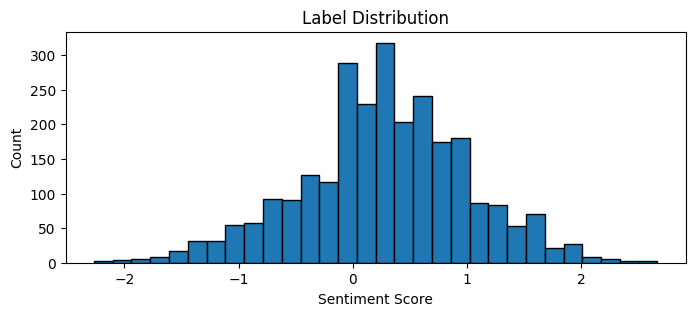

In [ ]:
import matplotlib.pyplot as plt

def check_data(loader, num_samples=3):
    text, audio, video, label = next(iter(loader))

    print("=== Shapes ===")
    print(f"Text:  {text.shape}")   # (batch, max_text_len)
    print(f"Audio: {audio.shape}")  # (batch, max_audio_len, 74)
    print(f"Video: {video.shape}")  # (batch, max_video_len, 35)
    print(f"Label: {label.shape}")  # (batch,)

    print("\n=== Data Types ===")
    print(f"Text:  {text.dtype}")
    print(f"Audio: {audio.dtype}")
    print(f"Video: {video.dtype}")
    print(f"Label: {label.dtype}")

    print("\n=== Value Ranges ===")
    print(f"Text  indices: min={text.min()},  max={text.max()}")
    print(f"Audio features: min={audio.min():.3f}, max={audio.max():.3f}")
    print(f"Video features: min={video.min():.3f}, max={video.max():.3f}")
    print(f"Labels: min={label.min():.3f}, max={label.max():.3f}")

    print("\n=== NaN / Inf Check ===")
    print(f"Audio has NaN: {torch.isnan(audio).any()}")
    print(f"Audio has Inf: {torch.isinf(audio).any()}")
    print(f"Video has NaN: {torch.isnan(video).any()}")
    print(f"Video has Inf: {torch.isinf(video).any()}")
    print(f"Label has NaN: {torch.isnan(label).any()}")

    print("\n=== Sample Labels ===")
    for i in range(num_samples):
        print(f"  Sample {i}: sentiment = {label[i]:.3f}")

    # Plot label distribution
    all_labels = []
    for _, _, _, l in loader:
        all_labels.extend(l.numpy())

    plt.figure(figsize=(8, 3))
    plt.hist(all_labels, bins=30, edgecolor='black')
    plt.title("Label Distribution")
    plt.xlabel("Sentiment Score")
    plt.ylabel("Count")
    plt.show()

check_data(train_loader)

# (5 points) Tensor Fusion

In [ ]:
class TensorFusion(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, audio_dim=74, video_dim=35,
                 encoder_out_dim=32, num_classes=1):
        super().__init__()
        self.text_encoder  = TextEncoder(vocab_size, embed_dim, encoder_out_dim)
        self.audio_encoder = AudioEncoder(audio_dim, 128, encoder_out_dim)
        self.video_encoder = VideoEncoder(video_dim, 64,  encoder_out_dim)

        d = encoder_out_dim + 1
        fused_dim = d * d * d

        self.fc = nn.Sequential(
            nn.Linear(fused_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, text, audio, video):
        text_out  = self.text_encoder(text)    # (batch, 32)
        audio_out = self.audio_encoder(audio)  # (batch, 32)
        video_out = self.video_encoder(video)  # (batch, 32)

        batch = text_out.shape[0]
        ones  = torch.ones(batch, 1).to(text_out.device)

        # text_i * audio_j * video_k = trimodal
        t = torch.cat([text_out,  ones], dim=-1)  # (batch, 33)
        a = torch.cat([audio_out, ones], dim=-1)  # (batch, 33)
        v = torch.cat([video_out, ones], dim=-1)  # (batch, 33)

        # Three-way outer product using einsum
        fused = torch.einsum('bi,bj,bk->bijk', t, a, v)  # (batch, 33, 33, 33)
        fused = fused.flatten(start_dim=1)                # (batch, 35937)

        return self.fc(fused)


In [ ]:
device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
criterion = nn.MSELoss()
model = TensorFusion(vocab_size=vocab_size).to(device)
optim = torch.optim.Adam(lat_model.parameters(), lr=1e-3)
num_epochs = 5

for epoch in range(num_epochs):
    train_loss = train(lat_model, train_loader, lat_optim, criterion, device)
    test_loss, mae, acc = test(model, test_loader, criterion, device)
    print(f"Epoch {epoch+1}/{num_epochs} | train loss: {train_loss:.4f} | test loss: {test_loss:.4f} | MAE: {mae:.4f} | Acc: {acc:.1f}%")

Epoch 1/5 | train loss: 214.2625 | test loss: 0.5635 | MAE: 0.5823 | Acc: 73.6%
Epoch 2/5 | train loss: 54.1886 | test loss: 0.5635 | MAE: 0.5823 | Acc: 73.6%
Epoch 3/5 | train loss: 40.4215 | test loss: 0.5635 | MAE: 0.5823 | Acc: 73.6%
Epoch 4/5 | train loss: 95.1183 | test loss: 0.5635 | MAE: 0.5823 | Acc: 73.6%
Epoch 5/5 | train loss: 174.7800 | test loss: 0.5635 | MAE: 0.5823 | Acc: 73.6%


# (5 Points) Low-Rank Tensor Fusion (LMF) Fusion

In [ ]:
class LowRankTensorFusion(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, audio_dim=74, video_dim=35,
                 encoder_out_dim=32, rank=4, num_classes=1):
        super().__init__()
        self.text_encoder  = TextEncoder(vocab_size, embed_dim, encoder_out_dim)
        self.audio_encoder = AudioEncoder(audio_dim, 128, encoder_out_dim)
        self.video_encoder = VideoEncoder(video_dim, 64,  encoder_out_dim)

        self.rank = rank
        d = encoder_out_dim + 1  # +1 for appended 1

        self.text_factor  = nn.Parameter(torch.randn(rank, d))
        self.audio_factor = nn.Parameter(torch.randn(rank, d))
        self.video_factor = nn.Parameter(torch.randn(rank, d))

        # Final fusion weight: maps rank → num_classes
        self.fusion_weight = nn.Parameter(torch.randn(rank, num_classes))

        self.fc = nn.Sequential(
            nn.Linear(num_classes, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, text, audio, video):
        text_out  = self.text_encoder(text)    # (batch, 32)
        audio_out = self.audio_encoder(audio)  # (batch, 32)
        video_out = self.video_encoder(video)  # (batch, 32)

        batch = text_out.shape[0]
        ones  = torch.ones(batch, 1).to(text_out.device)

        # Append 1 to each modality
        t = torch.cat([text_out,  ones], dim=-1)  # (batch, 33)
        a = torch.cat([audio_out, ones], dim=-1)  # (batch, 33)
        v = torch.cat([video_out, ones], dim=-1)  # (batch, 33)

        t_low = torch.einsum('bd,rd->br', t, self.text_factor)   # (batch, rank)
        a_low = torch.einsum('bd,rd->br', a, self.audio_factor)  # (batch, rank)
        v_low = torch.einsum('bd,rd->br', v, self.video_factor)  # (batch, rank)

        fused = t_low * a_low * v_low  # (batch, rank)

        out = torch.einsum('br,ro->bo', fused, self.fusion_weight)  # (batch, num_classes)

        return self.fc(out)

In [ ]:
device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
criterion = nn.MSELoss()
model = LowRankTensorFusion(vocab_size=vocab_size).to(device)
optim = torch.optim.Adam(lat_model.parameters(), lr=1e-3)
num_epochs = 5

for epoch in range(num_epochs):
    train_loss = train(lat_model, train_loader, lat_optim, criterion, device)
    test_loss, mae, acc = test(model, test_loader, criterion, device)
    print(f"Epoch {epoch+1}/{num_epochs} | train loss: {train_loss:.4f} | test loss: {test_loss:.4f} | MAE: {mae:.4f} | Acc: {acc:.1f}%")

Epoch 1/5 | train loss: 25.7128 | test loss: 71.0240 | MAE: 5.3721 | Acc: 73.6%
Epoch 2/5 | train loss: 10.0978 | test loss: 71.0240 | MAE: 5.3721 | Acc: 73.6%
Epoch 3/5 | train loss: 5.5576 | test loss: 71.0240 | MAE: 5.3721 | Acc: 73.6%
Epoch 4/5 | train loss: 4.4968 | test loss: 71.0240 | MAE: 5.3721 | Acc: 73.6%
Epoch 5/5 | train loss: 5.0558 | test loss: 71.0240 | MAE: 5.3721 | Acc: 73.6%


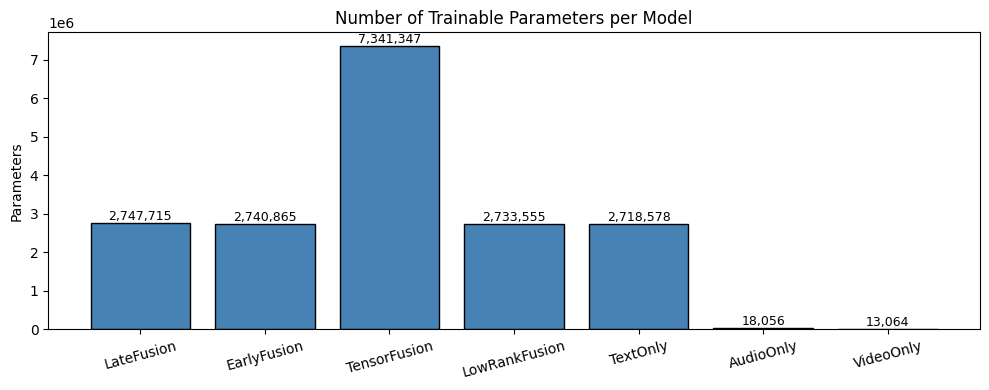

LateFusion          : 2,747,715 parameters
EarlyFusion         : 2,740,865 parameters
TensorFusion        : 7,341,347 parameters
LowRankFusion       : 2,733,555 parameters
TextOnly            : 2,718,578 parameters
AudioOnly           : 18,056 parameters
VideoOnly           : 13,064 parameters


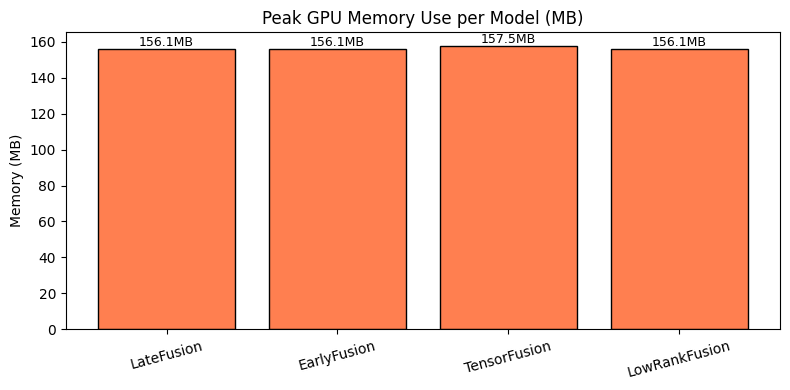

Training LateFusion...
  Converged at epoch 20 | final loss: 0.0568
Training EarlyFusion...
  Converged at epoch 20 | final loss: 1.8937
Training TensorFusion...
  Converged at epoch 20 | final loss: 0.1344
Training LowRankFusion...
  Converged at epoch 20 | final loss: 0.8389


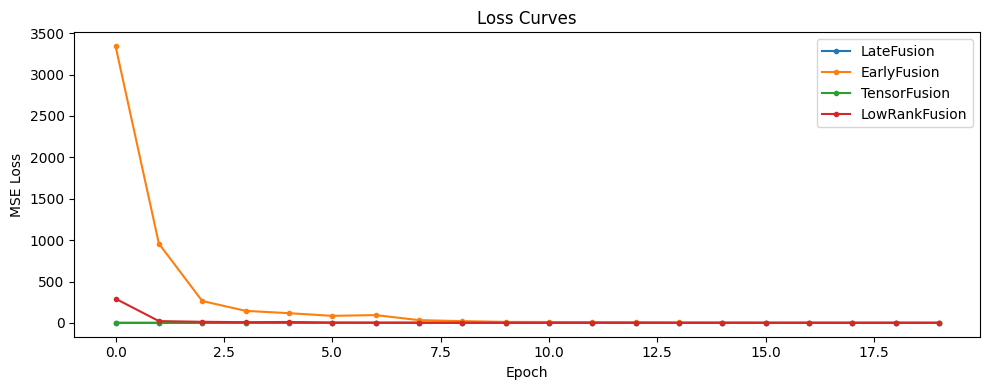

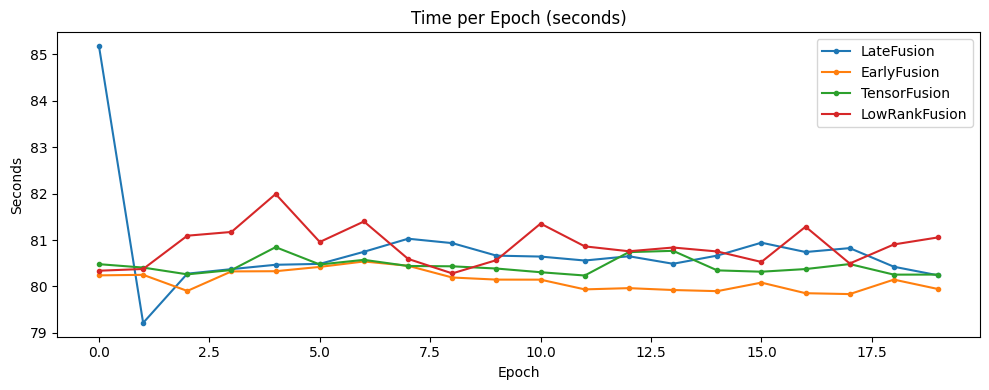

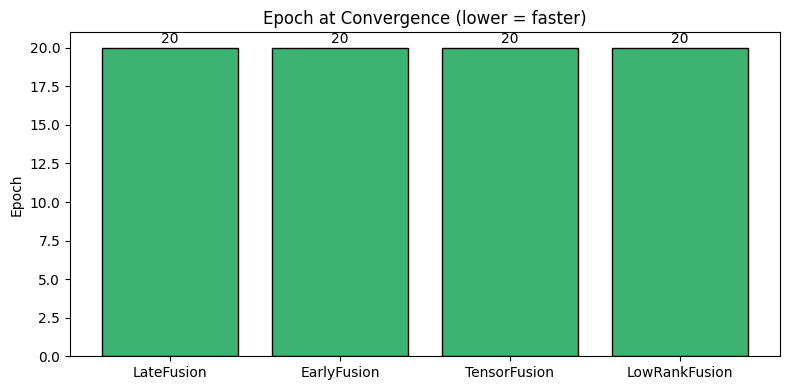

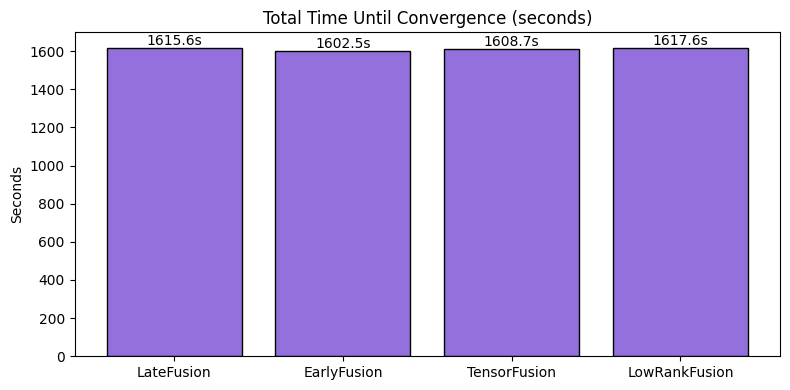

In [ ]:
import time
import torch
import matplotlib.pyplot as plt
import numpy as np

# ─── COUNT PARAMETERS ──────────────────────────────────────────────────────────

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

models = {
    'LateFusion':      LateFusion(vocab_size=vocab_size).to(device),
    'EarlyFusion':     EarlyFusionModel(vocab_size=vocab_size).to(device),
    'TensorFusion':    TensorFusion(vocab_size=vocab_size).to(device),
    'LowRankFusion':   LowRankTensorFusion(vocab_size=vocab_size).to(device),
    'TextOnly':        TextEncoder(vocab_size, 128, 64).to(device),
    'AudioOnly':       AudioEncoder(74, 128, 64).to(device),
    'VideoOnly':       VideoEncoder(35, 128, 64).to(device),
}

param_counts = {name: count_parameters(m) for name, m in models.items()}

plt.figure(figsize=(10, 4))
bars = plt.bar(param_counts.keys(), param_counts.values(), color='steelblue', edgecolor='black')
plt.title("Number of Trainable Parameters per Model")
plt.ylabel("Parameters")
plt.xticks(rotation=15)
for bar, val in zip(bars, param_counts.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f'{val:,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

for name, count in param_counts.items():
    print(f"{name:20s}: {count:,} parameters")


# ─── MEMORY USE ────────────────────────────────────────────────────────────────

def measure_memory(model, loader, device):
    model.eval()
    torch.cuda.reset_peak_memory_stats(device)
    text, audio, video, label = next(iter(loader))
    text, audio, video = text.to(device), audio.to(device), video.to(device)
    with torch.no_grad():
        _ = model(text, audio, video)
    mem = torch.cuda.max_memory_allocated(device) / (1024 ** 2)  # MB
    return mem

if torch.cuda.is_available():
    memory_use = {name: measure_memory(m, train_loader, device)
                  for name, m in models.items()
                  if name not in ['TextOnly', 'AudioOnly', 'VideoOnly']}

    plt.figure(figsize=(8, 4))
    bars = plt.bar(memory_use.keys(), memory_use.values(), color='coral', edgecolor='black')
    plt.title("Peak GPU Memory Use per Model (MB)")
    plt.ylabel("Memory (MB)")
    plt.xticks(rotation=15)
    for bar, val in zip(bars, memory_use.values()):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{val:.1f}MB', ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print("Memory measurement requires GPU — skipping")


# ─── TIME UNTIL CONVERGENCE ────────────────────────────────────────────────────

def train_and_track(model, loader, optimizer, criterion, device, num_epochs=10, patience=3):
    model.train()
    losses     = []
    epoch_times = []
    best_loss  = float('inf')
    no_improve = 0
    converged_at = num_epochs  # default if never converges early

    for epoch in range(num_epochs):
        start     = time.time()
        total_loss = 0
        for text, audio, video, label in loader:
            text, audio, video, label = (
                text.to(device), audio.to(device),
                video.to(device), label.to(device)
            )
            optimizer.zero_grad()
            out  = model(text, audio, video).squeeze(1)
            loss = criterion(out, label)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(loader)
        elapsed  = time.time() - start
        losses.append(avg_loss)
        epoch_times.append(elapsed)

        if avg_loss < best_loss - 1e-4:
            best_loss  = avg_loss
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                converged_at = epoch + 1
                break

    return losses, epoch_times, converged_at


criterion  = nn.MSELoss()
num_epochs = 20

fusion_models = {
    'LateFusion':    (LateFusion(vocab_size=vocab_size).to(device),          1e-3),
    'EarlyFusion':   (EarlyFusionModel(vocab_size=vocab_size).to(device),    1e-3),
    'TensorFusion':  (TensorFusion(vocab_size=vocab_size).to(device),        1e-3),
    'LowRankFusion': (LowRankTensorFusion(vocab_size=vocab_size).to(device), 1e-3),
}

results = {}
for name, (model, lr) in fusion_models.items():
    print(f"Training {name}...")
    optim = torch.optim.Adam(model.parameters(), lr=lr)
    losses, times, converged_at = train_and_track(model, train_loader, optim, criterion, device, num_epochs)
    results[name] = {'losses': losses, 'times': times, 'converged_at': converged_at}
    print(f"  Converged at epoch {converged_at} | final loss: {losses[-1]:.4f}")

# Plot 1: Loss curves
plt.figure(figsize=(10, 4))
for name, r in results.items():
    plt.plot(r['losses'], label=name, marker='o', markersize=3)
plt.title("Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.tight_layout()
plt.show()

# Plot 2: Time per epoch
plt.figure(figsize=(10, 4))
for name, r in results.items():
    plt.plot(r['times'], label=name, marker='o', markersize=3)
plt.title("Time per Epoch (seconds)")
plt.xlabel("Epoch")
plt.ylabel("Seconds")
plt.legend()
plt.tight_layout()
plt.show()

# Plot 3: Convergence epoch
plt.figure(figsize=(8, 4))
conv_epochs = {name: r['converged_at'] for name, r in results.items()}
bars = plt.bar(conv_epochs.keys(), conv_epochs.values(), color='mediumseagreen', edgecolor='black')
plt.title("Epoch at Convergence (lower = faster)")
plt.ylabel("Epoch")
for bar, val in zip(bars, conv_epochs.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             str(val), ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

# Plot 4: Total training time until convergence
plt.figure(figsize=(8, 4))
total_times = {name: sum(r['times'][:r['converged_at']]) for name, r in results.items()}
bars = plt.bar(total_times.keys(), total_times.values(), color='mediumpurple', edgecolor='black')
plt.title("Total Time Until Convergence (seconds)")
plt.ylabel("Seconds")
for bar, val in zip(bars, total_times.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{val:.1f}s', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

(10 points) In addition, create some visualizations of the following for each fusion:

* Number of parameters for each model (unimodal and multimodal)
* Memory Use
* Time until convergence

You are free to plot them here or through other means (like wandb). After doing so, discuss what are the pros and cons of unimodal versus multimodal models.

# Problem 6: Contrastive Learning (30 points)

For the next part of this HW, we will focus on contrastive learning. As a reminder, contrastive learning is a local, discrete alignment method used in machine learning. To explore this, we look at [CLIP](https://arxiv.org/pdf/2103.00020), a multimodal model developed by OpenAI that uses contrastive learning to align visual and textual data together.

**THIS IS JUST AN EXAMPLE, DO NOT LET THIS RESTRICT THE IMPLEMENTATION YOU WILL BE DOING.**

In [ ]:
!pip install ftfy regex tqdm
!pip install git+https://github.com/openai/CLIP.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.1 MB/s eta 0:00:00
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-ogfr69ms
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-ogfr69ms
  Resolved https://github.com/openai/CLIP.git to commit ded190a052fdf4585bd685cee5bc96e0310d2c93
  Preparing metadata (setup.py) ... done
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=bcdadfe07952db07fb82fde6fb3bf819c203feb289125c4b495e3c017891b931
  Stored in directory: /tmp/pip-ephem-wheel-cache-1glefl7n/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


In [ ]:
# Packages to import
import transformers
import torch
import clip
from PIL import Image
import requests
from io import BytesIO
import matplotlib.pyplot as plt


First, we create the model.

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Loading CLIP on {device}...")
model, preprocess = clip.load("ViT-B/32", device=device)

Loading CLIP on cuda...


100%|████████████████████████████████████████| 338M/338M [00:00<00:00, 463MiB/s]


Next, we will load an image to use. Note that we cannot use the MOSI dataset - we need to use raw data and the data points from the dataset already have extracted features. Upload a picture of someone smiling to use for this example (you can just find one online, save it and add to here).

In [ ]:
image_filename = "/content/Jennie18.jpg" # REPLACE WITH YOUR FILE
image = Image.open(image_filename).convert("RGB")

Now, we will prepare the prompt to use.

In [ ]:
# Options to pick from
text_options = ["a photo of a sad person", "a photo of a happy person", "a photo of an angry person"]
image_input = preprocess(image).unsqueeze(0).to(device)
text_inputs = clip.tokenize(text_options).to(device)

Now, let's run the inference and get the results!

In [ ]:
with torch.no_grad():
    image_features = model.encode_image(image_input)
    text_features = model.encode_text(text_inputs)

    # Normalize features
    image_features /= image_features.norm(dim=-1, keepdim=True)
    text_features /= text_features.norm(dim=-1, keepdim=True)

    # Calculate similarity (Dot Product)
    similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)
    values, indices = similarity[0].topk(3)

print(f"\nImage classified against: {text_options}")
print("-" * 30)
for value, index in zip(values, indices):
    print(f"{text_options[index]:>30s}: {100 * value.item():.2f}%")


Image classified against: ['a photo of a sad person', 'a photo of a happy person', 'a photo of an angry person']
------------------------------
     a photo of a happy person: 95.95%
       a photo of a sad person: 2.22%
    a photo of an angry person: 1.84%


(10 pts) We will now create, train and run zero-shot classification using contrastive learning for your own dataset. Fill in the missing information below for a generalize contrastive learning model. The training and zero-shot classification functions have been provided to you, through you may need to make slight modifications based on your dataset setup. **Design the model keeping in mind the modalities that you are specifically using. THE CLIP EXAMPLE ABOVE IS JUST TO SHOW CONTRASTIVE LEARNING IN ACTION - WE ARE NOT REQUIRING THAT YOU USE TEXT AND IMAGE AS THE MODALITIES OF CHOICE.** Try various queries, projectors, and settings on your dataset!

**You must use einsum where applicable.**


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

class CLModel(nn.Module):
    def __init__(self, dim_x1, dim_x2, embedded_dim, temp):
        super().__init__()

        # 1. Encoders for each modality
        self.text_encoder  = TextEncoder(vocab_size, 128, embedded_dim)
        self.audio_encoder = AudioEncoder(dim_x1, 128, embedded_dim)
        self.video_encoder = VideoEncoder(dim_x2, 64,  embedded_dim)

        # 2. Projectors: map each modality to a shared embedding space
        self.text_projector = nn.Sequential(
            nn.Linear(embedded_dim, embedded_dim),
            nn.ReLU(),
            nn.Linear(embedded_dim, embedded_dim)
        )
        self.audio_projector = nn.Sequential(
            nn.Linear(embedded_dim, embedded_dim),
            nn.ReLU(),
            nn.Linear(embedded_dim, embedded_dim)
        )
        self.video_projector = nn.Sequential(
            nn.Linear(embedded_dim, embedded_dim),
            nn.ReLU(),
            nn.Linear(embedded_dim, embedded_dim)
        )

        # 3. Learnable temperature
        self.scale = nn.Parameter(torch.ones([]) * np.log(1 / temp))

    def forward(self, text, audio, video):
      text_out  = self.text_encoder(text)
      audio_out = self.audio_encoder(audio)
      video_out = self.video_encoder(video)

      # Sanitize before projecting
      text_out  = torch.nan_to_num(text_out,  nan=0.0, posinf=1.0, neginf=-1.0)
      audio_out = torch.nan_to_num(audio_out, nan=0.0, posinf=1.0, neginf=-1.0)
      video_out = torch.nan_to_num(video_out, nan=0.0, posinf=1.0, neginf=-1.0)

      text_proj  = F.normalize(self.text_projector(text_out),  dim=-1)
      audio_proj = F.normalize(self.audio_projector(audio_out), dim=-1)
      video_proj = F.normalize(self.video_projector(video_out), dim=-1)

      # Sanitize after normalizing
      text_proj  = torch.nan_to_num(text_proj,  nan=0.0)
      audio_proj = torch.nan_to_num(audio_proj, nan=0.0)
      video_proj = torch.nan_to_num(video_proj, nan=0.0)

      return text_proj, audio_proj, video_proj


class ContrastiveLoss(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model   = model
        self.loss_fn = nn.CrossEntropyLoss()

    def forward(self, x1_emb, x2_emb):
        batch_size = x1_emb.shape[0]

        # Correct: divide by temperature, not multiply
        # scale = log(1/temp), so exp(scale) = 1/temp
        # dividing by temp = multiplying by 1/temp = multiplying by exp(scale)
        temp       = self.model.scale.exp()  # this is 1/temp ≈ 14.28, which is correct
        sim_matrix = torch.einsum('bi,ji->bj', x1_emb, x2_emb) * temp

        labels = torch.arange(batch_size).to(x1_emb.device)
        loss   = (
            self.loss_fn(sim_matrix,   labels) +
            self.loss_fn(sim_matrix.T, labels)
        ) / 2
        return loss


In [ ]:
def train_model(model, contrastive_loss, dataloader, val_loader=None, num_epochs=5, learning_rate=3e-4, device='cpu'):
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    model.to(device)

    train_losses = []
    val_losses   = []

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        for text, audio, video, _ in dataloader:
            text, audio, video = text.to(device), audio.to(device), video.to(device)
            text_proj, audio_proj, video_proj = model(text, audio, video)
            loss = (
                contrastive_loss(text_proj,  audio_proj) +
                contrastive_loss(text_proj,  video_proj) +
                contrastive_loss(audio_proj, video_proj)
            ) / 3
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            with torch.no_grad():
              cl_model.scale.clamp_(np.log(1/0.5), np.log(1/0.01))
            epoch_loss += loss.item()

        avg_train = epoch_loss / len(dataloader)
        train_losses.append(avg_train)

        if val_loader is not None:
            model.eval()
            val_loss = 0.0
            with torch.no_grad():
                for text, audio, video, _ in val_loader:
                    text, audio, video = text.to(device), audio.to(device), video.to(device)
                    text_proj, audio_proj, video_proj = model(text, audio, video)
                    loss = (
                        contrastive_loss(text_proj,  audio_proj) +
                        contrastive_loss(text_proj,  video_proj) +
                        contrastive_loss(audio_proj, video_proj)
                    ) / 3
                    val_loss += loss.item()
            avg_val = val_loss / len(val_loader)
            val_losses.append(avg_val)
            print(f"Epoch {epoch+1}/{num_epochs} | train: {avg_train:.4f} | val: {avg_val:.4f}")
        else:
            print(f"Epoch {epoch+1}/{num_epochs} | train: {avg_train:.4f}")

    # Plot
    plt.figure(figsize=(8, 4))
    plt.plot(train_losses, marker='o', markersize=4, label='Train Loss')
    if val_losses:
        plt.plot(val_losses, marker='o', markersize=4, label='Val Loss')
    plt.title("CLModel Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Contrastive Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return train_losses, val_losses

In [ ]:
# After training, we can now do zero-shot prediction
@torch.no_grad()
def predict_best_match(model, query_input, candidate_inputs, device):
    model.eval()

    query_feat = model.encoder_a(query_input.unsqueeze(0).to(device))
    query_emb = F.normalize(model.projector_a(query_feat), dim=1)

    cand_feat = model.encoder_b(candidate_inputs.to(device))
    cand_emb = F.normalize(model.projector_b(cand_feat), dim=1)

    scores = torch.einsum('id, jd -> ij', query_emb, cand_emb)

    best_match_idx = scores.argmax().item()

    print(f"Best match: {best_match_idx} with score {scores[0, best_match_idx].item()}")

    return best_match_idx, scores

In [ ]:
device = torch.device("cuda")
cl_model   = CLModel(dim_x1=74, dim_x2=35, embedded_dim=64, temp=0.07).to(device)
cl_loss_fn = ContrastiveLoss(cl_model).to(device)
cl_optim   = torch.optim.Adam(cl_model.parameters(), lr=1e-3)


Epoch 1/25 | train: 1.8237 | val: 3.2011
Epoch 2/25 | train: 1.7968 | val: 3.2706
Epoch 3/25 | train: 1.8035 | val: 3.2271
Epoch 4/25 | train: 1.7942 | val: 3.2070
Epoch 5/25 | train: 1.7928 | val: 3.2392
Epoch 6/25 | train: 1.7797 | val: 3.2276
Epoch 7/25 | train: 1.7680 | val: 3.2645
Epoch 8/25 | train: 1.7365 | val: 3.2960
Epoch 9/25 | train: 1.7351 | val: 3.2867
Epoch 10/25 | train: 1.7265 | val: 3.3116
Epoch 11/25 | train: 1.7392 | val: 3.2886
Epoch 12/25 | train: 1.7063 | val: 3.2994
Epoch 13/25 | train: 1.7119 | val: 3.3092
Epoch 14/25 | train: 1.6962 | val: 3.3646
Epoch 15/25 | train: 1.6842 | val: 3.3297
Epoch 16/25 | train: 1.6860 | val: 3.3858
Epoch 17/25 | train: 1.6639 | val: 3.2997
Epoch 18/25 | train: 1.6629 | val: 3.3482
Epoch 19/25 | train: 1.6776 | val: 3.3621
Epoch 20/25 | train: 1.6458 | val: 3.3967
Epoch 21/25 | train: 1.6232 | val: 3.4148
Epoch 22/25 | train: 1.6221 | val: 3.4184
Epoch 23/25 | train: 1.6175 | val: 3.3711
Epoch 24/25 | train: 1.6123 | val: 3.4187
E

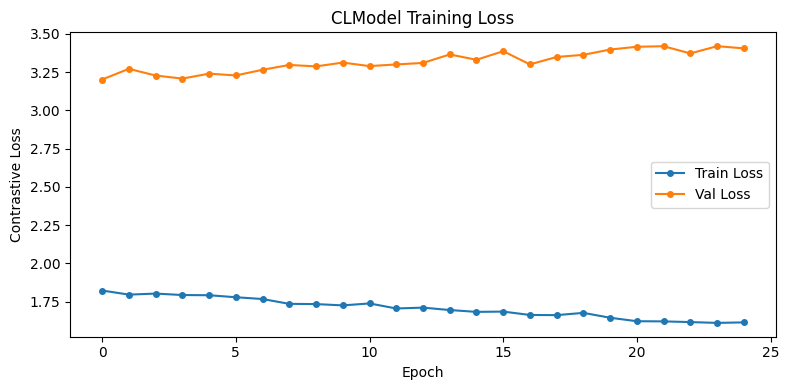

In [ ]:
losses, val_losses = train_model(cl_model, cl_loss_fn, train_loader,
                                   val_loader=test_loader, num_epochs=25,
                                   learning_rate=3e-4, device=device)

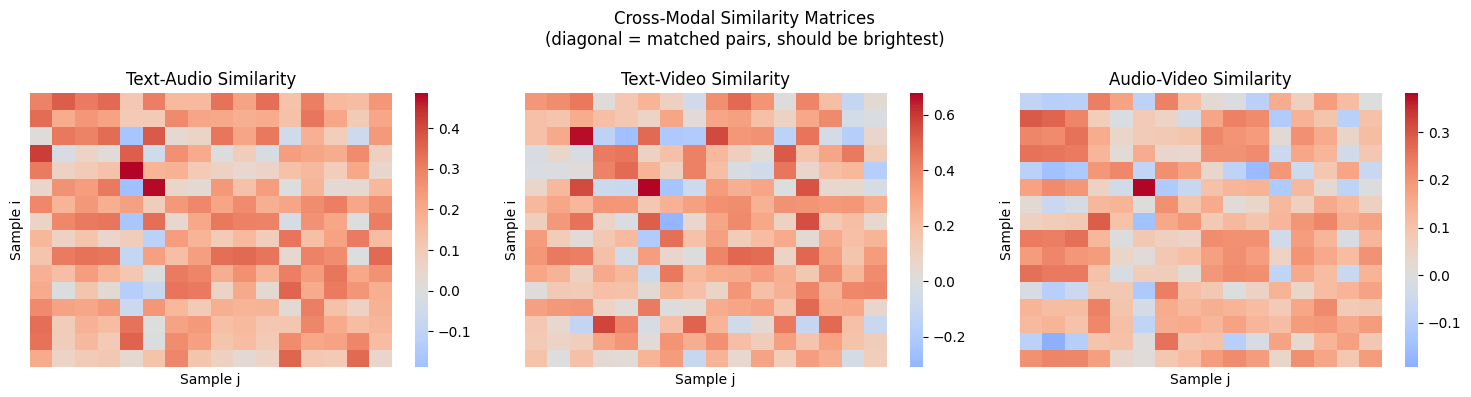

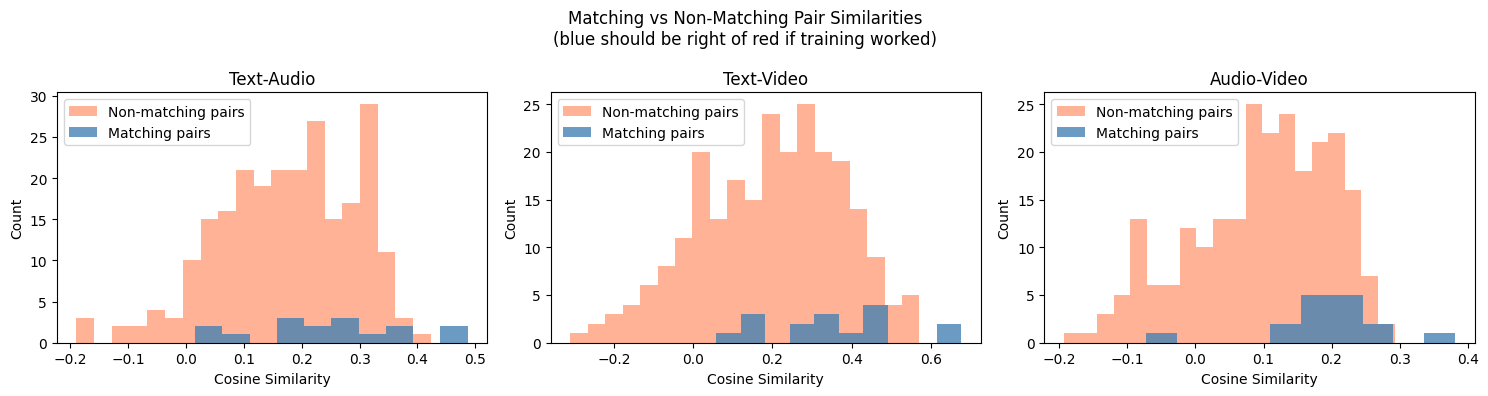

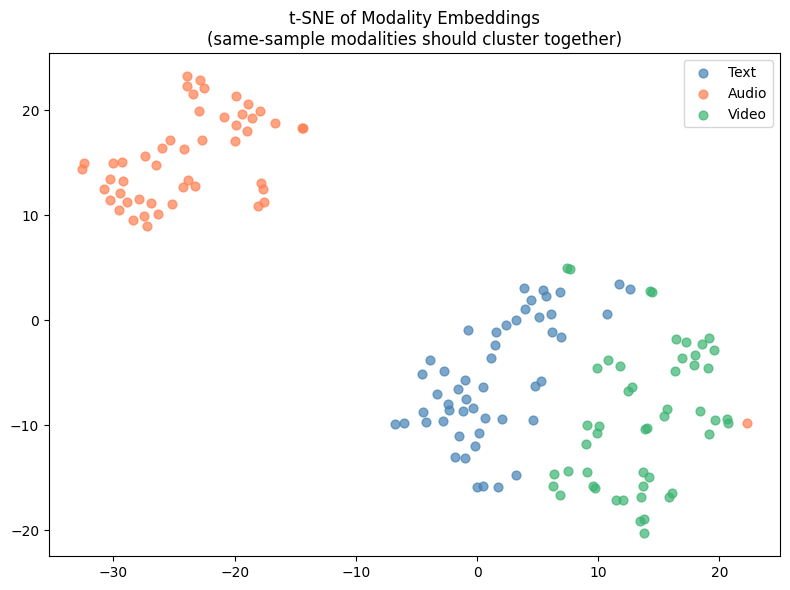

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import numpy as np

def visualize_cl_model(model, loader, device, num_batches=10):
    model.eval()

    all_text  = []
    all_audio = []
    all_video = []

    with torch.no_grad():
        for i, (text, audio, video, _) in enumerate(loader):
            if i >= num_batches:
                break
            text, audio, video = text.to(device), audio.to(device), video.to(device)
            text_proj, audio_proj, video_proj = model(text, audio, video)
            all_text.append(text_proj.cpu().numpy())
            all_audio.append(audio_proj.cpu().numpy())
            all_video.append(video_proj.cpu().numpy())

    all_text  = np.concatenate(all_text)
    all_audio = np.concatenate(all_audio)
    all_video = np.concatenate(all_video)

    # ── 1. SIMILARITY MATRIX ───────────────────────────────────────────────────
    # shows how well matched text-audio-video are for the same sample
    n = 16  # show first 16 samples
    ta_sim = all_text[:n] @ all_audio[:n].T
    tv_sim = all_text[:n] @ all_video[:n].T
    av_sim = all_audio[:n] @ all_video[:n].T

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, sim, title in zip(axes,
                               [ta_sim, tv_sim, av_sim],
                               ['Text-Audio', 'Text-Video', 'Audio-Video']):
        sns.heatmap(sim, ax=ax, cmap='coolwarm', center=0,
                    xticklabels=False, yticklabels=False)
        ax.set_title(f'{title} Similarity')
        ax.set_xlabel('Sample j')
        ax.set_ylabel('Sample i')
    plt.suptitle("Cross-Modal Similarity Matrices\n(diagonal = matched pairs, should be brightest)")
    plt.tight_layout()
    plt.show()

    # ── 2. DIAGONAL VS OFF-DIAGONAL SIMILARITY ─────────────────────────────────
    # if training worked, diagonal (matched pairs) should be higher than off-diagonal
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, sim, title in zip(axes,
                               [ta_sim, tv_sim, av_sim],
                               ['Text-Audio', 'Text-Video', 'Audio-Video']):
        diag     = np.diag(sim)
        off_diag = sim[~np.eye(n, dtype=bool)]
        ax.hist(off_diag, bins=20, alpha=0.6, label='Non-matching pairs', color='coral')
        ax.hist(diag,     bins=10, alpha=0.8, label='Matching pairs',     color='steelblue')
        ax.set_title(f'{title}')
        ax.set_xlabel('Cosine Similarity')
        ax.set_ylabel('Count')
        ax.legend()
    plt.suptitle("Matching vs Non-Matching Pair Similarities\n(blue should be right of red if training worked)")
    plt.tight_layout()
    plt.show()

    # ── 3. T-SNE: ARE SAME-SAMPLE MODALITIES CLOSE TOGETHER? ──────────────────
    # combine all modalities and color by modality type
    # points from the same sample should cluster together
    combined = np.concatenate([all_text[:50], all_audio[:50], all_video[:50]])
    labels   = ['Text'] * 50 + ['Audio'] * 50 + ['Video'] * 50

    tsne      = TSNE(n_components=2, random_state=42, perplexity=15)
    embedded  = tsne.fit_transform(combined)

    colors = {'Text': 'steelblue', 'Audio': 'coral', 'Video': 'mediumseagreen'}
    plt.figure(figsize=(8, 6))
    for modality in ['Text', 'Audio', 'Video']:
        mask = [l == modality for l in labels]
        pts  = embedded[mask]
        plt.scatter(pts[:, 0], pts[:, 1],
                    c=colors[modality], label=modality, alpha=0.7, s=40)
    plt.title("t-SNE of Modality Embeddings\n(same-sample modalities should cluster together)")
    plt.legend()
    plt.tight_layout()
    plt.show()



visualize_cl_model(cl_model, test_loader, device)

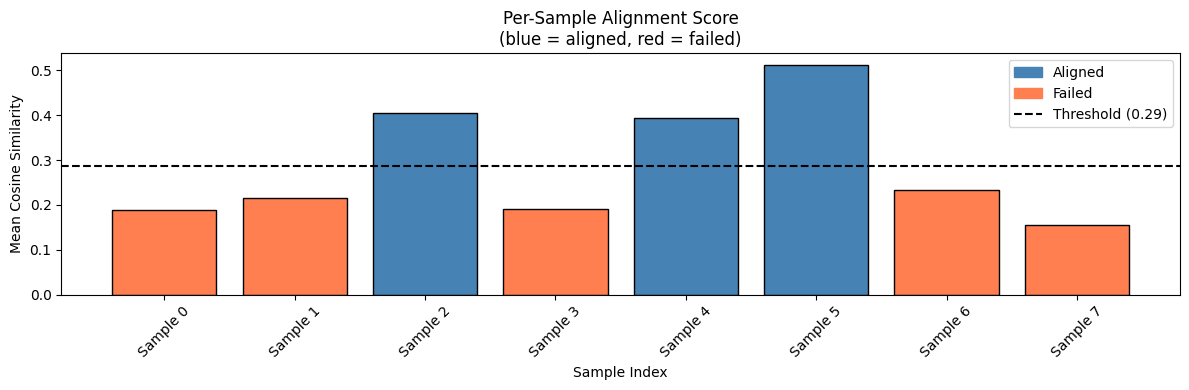

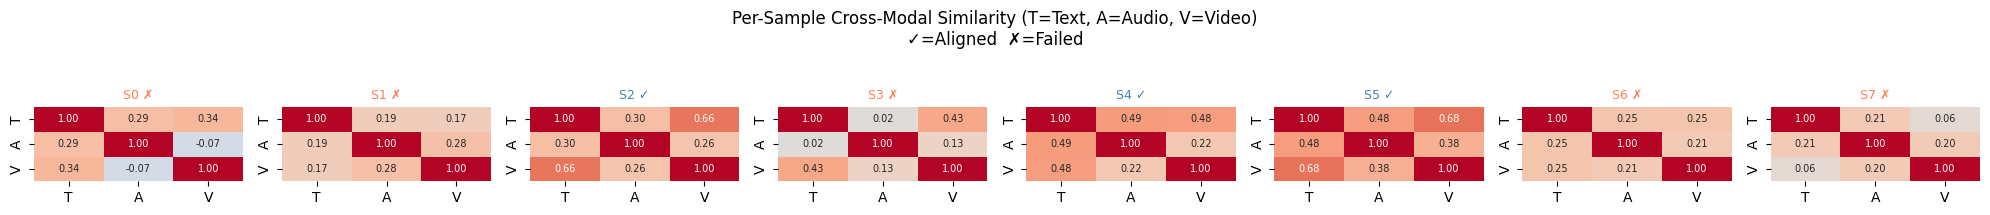

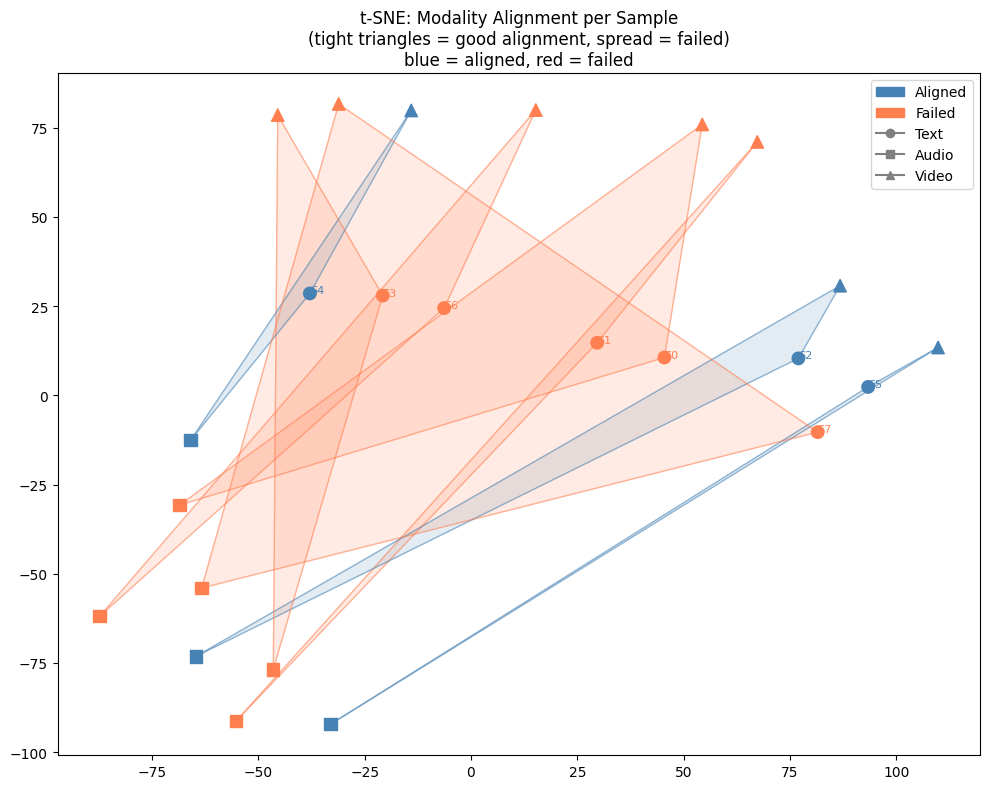

=== Aligned Samples ===
  Sample 2 (score=0.405): sp my name is julie and i sp am a...
  Sample 4 (score=0.395): sp i sp believe sp that sp the consumers sp...
  Sample 5 (score=0.513): sp alright we're talking about humor sp and sp in...

=== Failed Samples ===
  Sample 0 (score=0.188): sp i do see picky eaters but i see everything...
  Sample 1 (score=0.215): hi sp i'm kate and i'm here to talk about...
  Sample 3 (score=0.192): betty sp ann bowser sp spanish soap operas or sp...
  Sample 6 (score=0.234): i'm sp not sp confident sp that the global sp...
  Sample 7 (score=0.155): sp what is narrative style sp in literature sp it...


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
import torch

def visualize_alignment(model, loader, device, num_samples=8):
    model.eval()

    all_text_proj  = []
    all_audio_proj = []
    all_video_proj = []
    all_text_raw   = []

    with torch.no_grad():
        for text, audio, video, _ in loader:
            text, audio, video = text.to(device), audio.to(device), video.to(device)
            text_proj, audio_proj, video_proj = model(text, audio, video)
            all_text_proj.append(text_proj.cpu().numpy())
            all_audio_proj.append(audio_proj.cpu().numpy())
            all_video_proj.append(video_proj.cpu().numpy())
            all_text_raw.append(text.cpu().numpy())
            if len(all_text_proj) * loader.batch_size >= 64:
                break

    text_emb  = np.concatenate(all_text_proj)[:num_samples]
    audio_emb = np.concatenate(all_audio_proj)[:num_samples]
    video_emb = np.concatenate(all_video_proj)[:num_samples]
    text_raw  = np.concatenate(all_text_raw)[:num_samples]

    # ── 1. PER-SAMPLE ALIGNMENT SCORE ─────────────────────────────────────────
    # For each sample, compute cosine similarity between its modalities
    # A well-aligned sample has high similarity across all three pairs
    ta_scores = np.array([text_emb[i] @ audio_emb[i] for i in range(num_samples)])
    tv_scores = np.array([text_emb[i] @ video_emb[i] for i in range(num_samples)])
    av_scores = np.array([audio_emb[i] @ video_emb[i] for i in range(num_samples)])
    avg_scores = (ta_scores + tv_scores + av_scores) / 3

    # Threshold: above = aligned, below = failed
    threshold = avg_scores.mean()
    aligned   = avg_scores >= threshold

    fig, ax = plt.subplots(figsize=(12, 4))
    colors = ['steelblue' if a else 'coral' for a in aligned]
    bars   = ax.bar(range(num_samples), avg_scores, color=colors, edgecolor='black')
    ax.axhline(threshold, color='black', linestyle='--', label=f'Mean threshold ({threshold:.2f})')
    ax.set_xlabel("Sample Index")
    ax.set_ylabel("Mean Cosine Similarity")
    ax.set_title("Per-Sample Alignment Score\n(blue = aligned, red = failed)")
    ax.set_xticks(range(num_samples))
    ax.set_xticklabels([f'Sample {i}' for i in range(num_samples)], rotation=45)
    good_patch = mpatches.Patch(color='steelblue', label='Aligned')
    fail_patch = mpatches.Patch(color='coral',     label='Failed')
    ax.legend(handles=[good_patch, fail_patch,
                        plt.Line2D([0], [0], color='black', linestyle='--',
                                   label=f'Threshold ({threshold:.2f})')])
    plt.tight_layout()
    plt.show()

    # ── 2. PAIRWISE SIMILARITY HEATMAP PER SAMPLE ──────────────────────────────
    # For each sample show text-audio, text-video, audio-video similarity
    fig, axes = plt.subplots(1, num_samples, figsize=(20, 2))
    for i, ax in enumerate(axes):
        sim = np.array([
            [1.0,         ta_scores[i], tv_scores[i]],
            [ta_scores[i], 1.0,         av_scores[i]],
            [tv_scores[i], av_scores[i], 1.0        ]
        ])
        sns.heatmap(sim, ax=ax, cmap='coolwarm', vmin=-1, vmax=1,
                    xticklabels=['T', 'A', 'V'],
                    yticklabels=['T', 'A', 'V'],
                    annot=True, fmt='.2f', annot_kws={'size': 7},
                    cbar=False)
        status = '✓' if aligned[i] else '✗'
        ax.set_title(f'S{i} {status}', fontsize=9,
                     color='steelblue' if aligned[i] else 'coral')
    plt.suptitle("Per-Sample Cross-Modal Similarity (T=Text, A=Audio, V=Video)\n✓=Aligned  ✗=Failed", y=1.05)
    plt.tight_layout()
    plt.show()

    # ── 3. T-SNE: CONNECTED SAME-SAMPLE MODALITIES ────────────────────────────
    # Draw lines connecting text-audio-video for the same sample
    # Short lines = good alignment, long lines = failed alignment
    combined = np.concatenate([text_emb, audio_emb, video_emb])
    tsne     = TSNE(n_components=2, random_state=42, perplexity=5)
    embedded = tsne.fit_transform(combined)

    t_pts = embedded[:num_samples]
    a_pts = embedded[num_samples:2*num_samples]
    v_pts = embedded[2*num_samples:]

    fig, ax = plt.subplots(figsize=(10, 8))
    for i in range(num_samples):
        color  = 'steelblue' if aligned[i] else 'coral'
        # Draw triangle connecting text, audio, video for this sample
        triangle = plt.Polygon([t_pts[i], a_pts[i], v_pts[i]],
                                fill=True, alpha=0.15, color=color)
        ax.add_patch(triangle)
        for pts_a, pts_b in [(t_pts, a_pts), (t_pts, v_pts), (a_pts, v_pts)]:
            ax.plot([pts_a[i, 0], pts_b[i, 0]],
                    [pts_a[i, 1], pts_b[i, 1]],
                    color=color, alpha=0.5, linewidth=1)
        ax.annotate(f'S{i}', xy=t_pts[i], fontsize=8, color=color)

    ax.scatter(t_pts[:, 0], t_pts[:, 1], c=['steelblue' if a else 'coral' for a in aligned],
               marker='o', s=80, label='Text',  zorder=5)
    ax.scatter(a_pts[:, 0], a_pts[:, 1], c=['steelblue' if a else 'coral' for a in aligned],
               marker='s', s=80, label='Audio', zorder=5)
    ax.scatter(v_pts[:, 0], v_pts[:, 1], c=['steelblue' if a else 'coral' for a in aligned],
               marker='^', s=80, label='Video', zorder=5)

    good_patch = mpatches.Patch(color='steelblue', label='Aligned')
    fail_patch = mpatches.Patch(color='coral',     label='Failed')
    ax.legend(handles=[good_patch, fail_patch,
                        plt.Line2D([0], [0], marker='o', color='gray', label='Text'),
                        plt.Line2D([0], [0], marker='s', color='gray', label='Audio'),
                        plt.Line2D([0], [0], marker='^', color='gray', label='Video')])
    ax.set_title("t-SNE: Modality Alignment per Sample\n"
                 "(tight triangles = good alignment, spread = failed)\n"
                 "blue = aligned, red = failed")
    plt.tight_layout()
    plt.show()

    # ── 4. PRINT EXAMPLES ─────────────────────────────────────────────────────
    idx2word = {v: k for k, v in word2idx.items()}
    print("=== Aligned Samples ===")
    for i in range(num_samples):
        if aligned[i]:
            words = [idx2word.get(w, '<unk>') for w in text_raw[i] if w != word2idx['<pad>']]
            print(f"  Sample {i} (score={avg_scores[i]:.3f}): {' '.join(words[:10])}...")

    print("\n=== Failed Samples ===")
    for i in range(num_samples):
        if not aligned[i]:
            words = [idx2word.get(w, '<unk>') for w in text_raw[i] if w != word2idx['<pad>']]
            print(f"  Sample {i} (score={avg_scores[i]:.3f}): {' '.join(words[:10])}...")


visualize_alignment(cl_model, test_loader, device)

=== Cosine Similarity in Original Space ===
Text-Audio      | matched: 0.230 | unmatched: 0.155 | gap: 0.075 ✓ working
Text-Video      | matched: 0.304 | unmatched: 0.184 | gap: 0.120 ✓ working
Audio-Video     | matched: 0.200 | unmatched: 0.088 | gap: 0.112 ✓ working


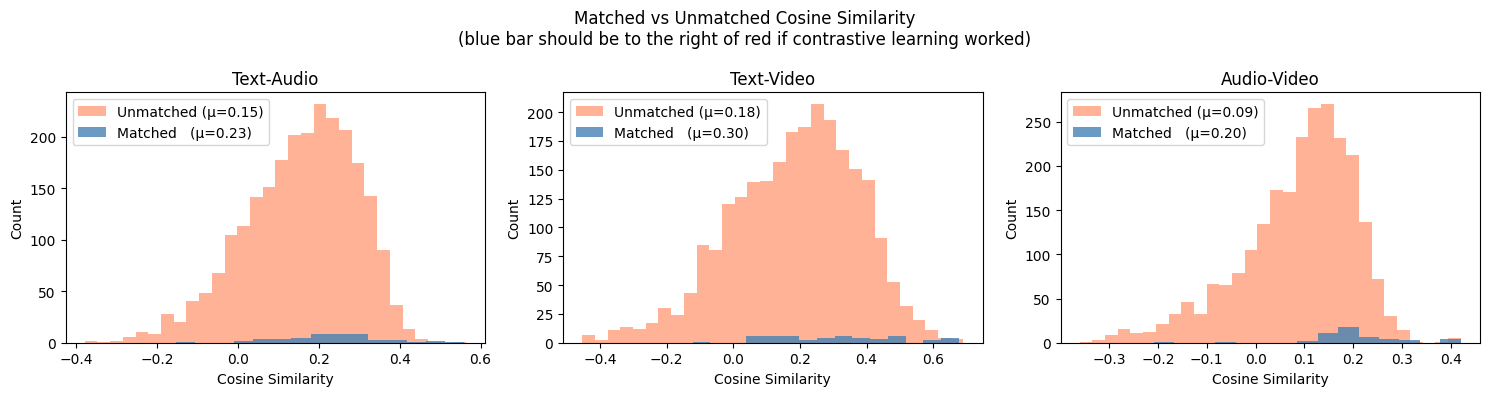

In [ ]:
def check_actual_alignment(model, loader, device, n=50):
    model.eval()
    all_text, all_audio, all_video = [], [], []

    with torch.no_grad():
        for i, (text, audio, video, _) in enumerate(loader):
            if sum(len(x) for x in all_text) >= n:
                break
            text, audio, video = text.to(device), audio.to(device), video.to(device)
            t, a, v = model(text, audio, video)
            all_text.append(t.cpu().numpy())
            all_audio.append(a.cpu().numpy())
            all_video.append(v.cpu().numpy())

    text_emb  = np.concatenate(all_text)[:n]
    audio_emb = np.concatenate(all_audio)[:n]
    video_emb = np.concatenate(all_video)[:n]

    # Similarity matrices
    ta_sim = text_emb @ audio_emb.T
    tv_sim = text_emb @ video_emb.T
    av_sim = audio_emb @ video_emb.T

    print("=== Cosine Similarity in Original Space ===")
    for sim, name in [(ta_sim, 'Text-Audio'), (tv_sim, 'Text-Video'), (av_sim, 'Audio-Video')]:
        matched   = np.diag(sim).mean()
        unmatched = sim[~np.eye(n, dtype=bool)].mean()
        gap       = matched - unmatched
        status    = '✓ working' if gap > 0 else '✗ not working'
        print(f"{name:15s} | matched: {matched:.3f} | unmatched: {unmatched:.3f} | gap: {gap:.3f} {status}")

    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, sim, title in zip(axes,
                               [ta_sim, tv_sim, av_sim],
                               ['Text-Audio', 'Text-Video', 'Audio-Video']):
        diag     = np.diag(sim)
        off_diag = sim[~np.eye(n, dtype=bool)]
        ax.hist(off_diag, bins=30, alpha=0.6, color='coral',
                label=f'Unmatched (μ={off_diag.mean():.2f})')
        ax.hist(diag,     bins=15, alpha=0.8, color='steelblue',
                label=f'Matched   (μ={diag.mean():.2f})')
        ax.set_title(title)
        ax.set_xlabel('Cosine Similarity')
        ax.set_ylabel('Count')
        ax.legend()
    plt.suptitle("Matched vs Unmatched Cosine Similarity\n"
                 "(blue bar should be to the right of red if contrastive learning worked)")
    plt.tight_layout()
    plt.show()


# Function call
check_actual_alignment(cl_model, test_loader, device, n=50)

Now answer some of these questions:

1. (5 points) Any suprising results from using this on your dataset?
2. (5 points) Typically, cross-entropy loss is used in this contrastive learning, why is this the case?
3. (10 points) Create some visual examples of the data post alignment. Can you point out samples where the alignment worked and where it failed? Why do you suspect that is?

# Problem 7: Reflection (10 points)

Now we'll take some time to reflect on this homework. Take some time to discuss the following:

1. (5 points) What concept did you find the most interesting?
2. (5 points) Which concepts (if any) do you see being useful towards your goal? Why? If there was none, discuss why.
3. (0 points, optional) Is there a topic that was discussed during lectures up to the release of the assignment that you wished was covered in the homework? Any from the assignment that you wanted there to be touched upon more? Any feedback you have in general for homeworks or the class?